This is a parallel notebook to _process_low_bckg_data.py_ script intended for testing the different steps involved in the data processing.

In [486]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import argparse
import csv
import glob
from invisible_cities.core.core_functions import in_range
from invisible_cities.reco.corrections import apply_all_correction, read_maps
from invisible_cities.types.symbols import NormMethod, NormStrategy
from joblib import delayed, Parallel
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.interpolate import griddata, interp1d 
from scipy.spatial.distance import cdist
from sklearn.exceptions import NotFittedError
from sklearn.neighbors import BallTree, NearestNeighbors
from typing import Callable, List, Tuple

# Styling Plot
crudo.pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Configuration

In [487]:
# OUTPUT FILENAME TAG
VERSION_TAG = 'p2_zemrude_v2'

# DIRECTORIES, PATHS & FILES
DATA_DIR   = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Sophronia/Low_background/'
ICAROS_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Icaros/Low_background/2025/'
OUTPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/'

RUNS_INFO_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/runs_information.csv')

SUMMARY_FILENAME = 'summary_' + VERSION_TAG +'.csv'     # Choose your name
SUMMARY_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/', SUMMARY_FILENAME)

# KEYS
DORO_KEY = 'DST/Events'
SOPH_KEY = 'RECO/Events'
KR_KEY = 'krmap/krmap'

# COLUMNS TO USE
DORO_COLUMNS = ['event', 'time', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'DT', 'X', 'Y', 'Z']
SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'Z', 'Q', 'E']
FINAL_SOPH_COLUMNS = ['event', 'time', 'npeak', 'X', 'Y', 'DT', 'Z', 'Ec', 'cluster']

EVENT_LEVEL_COLS = ['nS1', 'nS2', 'old_n_hits']

# CUTFLOWS
CUT_NAMES = ['Sophronia', 'Clean', 'Z_Positive', 'S1_Cut']

# ---------------------
# PROCESSING PARAMETERS
# ---------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- S1e Correction ---
# Values from Radon analysis: S1e = m * DT + b
DT_CATH = 1350               # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values from S1e vs DT plot

# --- Hits Clusterizer ---
CLUSTERING_PARAMS = dict(eps = 1.8, min_samples = 5, scale_xy = 15.55, scale_z = 4.0)
CLUSTER_FUNCTION = crudo.tf.hits_clusterizer(CLUSTERING_PARAMS)

# -----------------------------
# ALPHA/ELECTRON DISCRIMINATION
# -----------------------------
SIZE_THRESHOLD = 2e3           # in [# of hits]
S1_ENERGY_THRESHOLD = 900      # in [PE]

# ----------------
# DETECTOR REGIONS
# ----------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# ---------
# SELECTION
# ---------
# --- High Energy Scale Correction ---
# Values from Thorium analysis
M_HE_SCALE = 0.955348
B_HE_SCALE = 0.008559
# # PE Values
# M_HE_SCALE = 4.80e-06
# B_HE_SCALE = 0.0094

# --- Trigger 2 Efficiency Cut ---
# Events with event-level energy below this are removed to account for trigger efficiency
TRG2_THRESHOLD = 0.5   # in [MeV]

# Preliminary

In [488]:
# --- Parse Arguments
RUN_NUMBER = 15733
KR_CITY = 'zemrude'

In [489]:
RUNS_INFO_DF = pd.read_csv(RUNS_INFO_PATH, index_col='run_number')
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()
if RUN_NUMBER not in RUNS_INFO_DF.index:
    print(f"   Error: Run {RUN_NUMBER} not found in runs information.", file=sys.stderr)
    sys.exit(1)
# Extract run information from the dataframe
RUN_DURATION = RUNS_INFO_DF.at[RUN_NUMBER, 'duration']
RUN_OK   = RUNS_INFO_DF.at[RUN_NUMBER, 'OK']
RUN_LOST = RUNS_INFO_DF.at[RUN_NUMBER, 'LOST']

print(f"----- Testing with RUN {RUN_NUMBER} -----")
print(f"Duration: {RUN_DURATION} s ({type(RUN_DURATION)}), OK: {RUN_OK} ({type(RUN_OK)}), LOST: {RUN_LOST} ({type(RUN_LOST)})")

kr_file = next((f for f in os.listdir(ICAROS_DIR) if f'run_{RUN_NUMBER}' in f and f.endswith('.zemrude.h5')), None)
if not kr_file:
    raise FileNotFoundError(f"   Error: NO Kr map file found for run {RUN_NUMBER} in {ICAROS_DIR}")
    sys.exit(1)
KR_PATH = os.path.join(ICAROS_DIR, kr_file)
print(f"Kr map file found: {kr_file}")

# Construct specific list of files to process based on run number
files_to_process = []
# ----- LDC Loop ----- #
for ldc in range(1, 2):
    # Load the HDF5 file
    h5_path = os.path.join(DATA_DIR, f'run_{RUN_NUMBER}_ldc{ldc}_trg2_sophronia.h5')
    if os.path.isfile(h5_path):
        files_to_process.append(h5_path)

if not files_to_process:
    print(f"   Error: No .h5 files found to process.", file=sys.stderr)
    sys.exit(1)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("----------------------------------")
print("Files to Process:")
for fp in files_to_process:
    print(os.path.basename(fp))
print(f"Output Directory: {OUTPUT_DIR}")
print("----------------------------------")

----- Testing with RUN 15733 -----
Duration: 86919 s (<class 'numpy.int64'>), OK: 30475 (<class 'numpy.int64'>), LOST: 10027 (<class 'numpy.int64'>)
Kr map file found: run_15733.zemrude-test-7-ge5dc049e.20250717-26-g211f149.KrDesman.zemrude.h5
----------------------------------
Files to Process:
run_15733_ldc1_trg2_sophronia.h5
Output Directory: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/
----------------------------------


# Processing

In the processing script, we do not concatenate at first, cause' we use parallelization.

### Load Dorothea & Sophronia

In [490]:
# All dataframes to concatenate later
all_doros = []
all_sophs = []

for filepath in files_to_process[:2]:
    # Here we use all the columns, but they can be reduced if needed
    file_doro = pd.read_hdf(filepath, key=DORO_KEY);    all_doros.append(file_doro)
    file_soph = pd.read_hdf(filepath, key=SOPH_KEY);    all_sophs.append(file_soph)

# Concatenate all dataframes
df_doro = pd.concat(all_doros, ignore_index=True)
df_soph = pd.concat(all_sophs, ignore_index=True)

# First, store original event size from Sophronia into Dorothea dataframe
df_og_evt_size = df_soph.groupby('event').size().rename('old_n_hits').reset_index()
df_doro = df_doro.merge(df_og_evt_size, on='event', how='left')

# Compute Z in [mm]
df_soph.rename(columns={'Z': 'DT'}, inplace=True)
df_soph['Z'] = df_soph['DT'] * V_DRIFT
print(f"Run {RUN_NUMBER}: {df_soph['event'].nunique()} events loaded.")

Run 15733: 4204 events loaded.


### NO Spurious Hits

#### Clustering

We first cluster hits in each event using DBSCAN algorithm, tagging -1 hits as noisy hits.

In [491]:
df_soph = CLUSTER_FUNCTION(df_soph)
df_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster
0,729,1.758896e+09,0,70.205942,5.904926,1,335.525,14.175,0.0,0.0,1.513556,5.094590,54.695764,-1.0,0.000282,-1,-1.0,1.309226,-1
1,729,1.758896e+09,0,70.205942,5.904926,1,-297.025,137.575,0.0,0.0,5.551661,6.198846,52.750450,-1.0,0.000278,-1,-1.0,4.802187,-1
2,729,1.758896e+09,0,70.205942,5.904926,1,-250.375,137.575,0.0,0.0,9.498283,5.173252,18.136207,-1.0,0.000094,-1,-1.0,8.216015,-1
3,729,1.758896e+09,0,70.205942,5.904926,1,243.225,-356.525,0.0,0.0,9.498283,5.522325,19.359973,-1.0,0.000112,-1,-1.0,8.216015,-1
4,729,1.758896e+09,0,70.205942,5.904926,1,165.475,322.675,0.0,0.0,9.498283,5.275735,18.495487,-1.0,0.000100,-1,-1.0,8.216015,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15540763,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,214.325,0.0,0.0,1368.305500,7.229555,6.293980,-1.0,0.000043,-1,-1.0,1183.584257,0
15540764,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,229.875,0.0,0.0,1368.305500,7.330564,6.381917,-1.0,0.000046,-1,-1.0,1183.584257,0
15540765,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,245.425,0.0,0.0,1368.305500,6.875893,5.986085,-1.0,0.000046,-1,-1.0,1183.584257,0
15540766,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,260.975,0.0,0.0,1368.305500,10.088025,8.782536,-1.0,0.000077,-1,-1.0,1183.584257,0


Event 1373674:


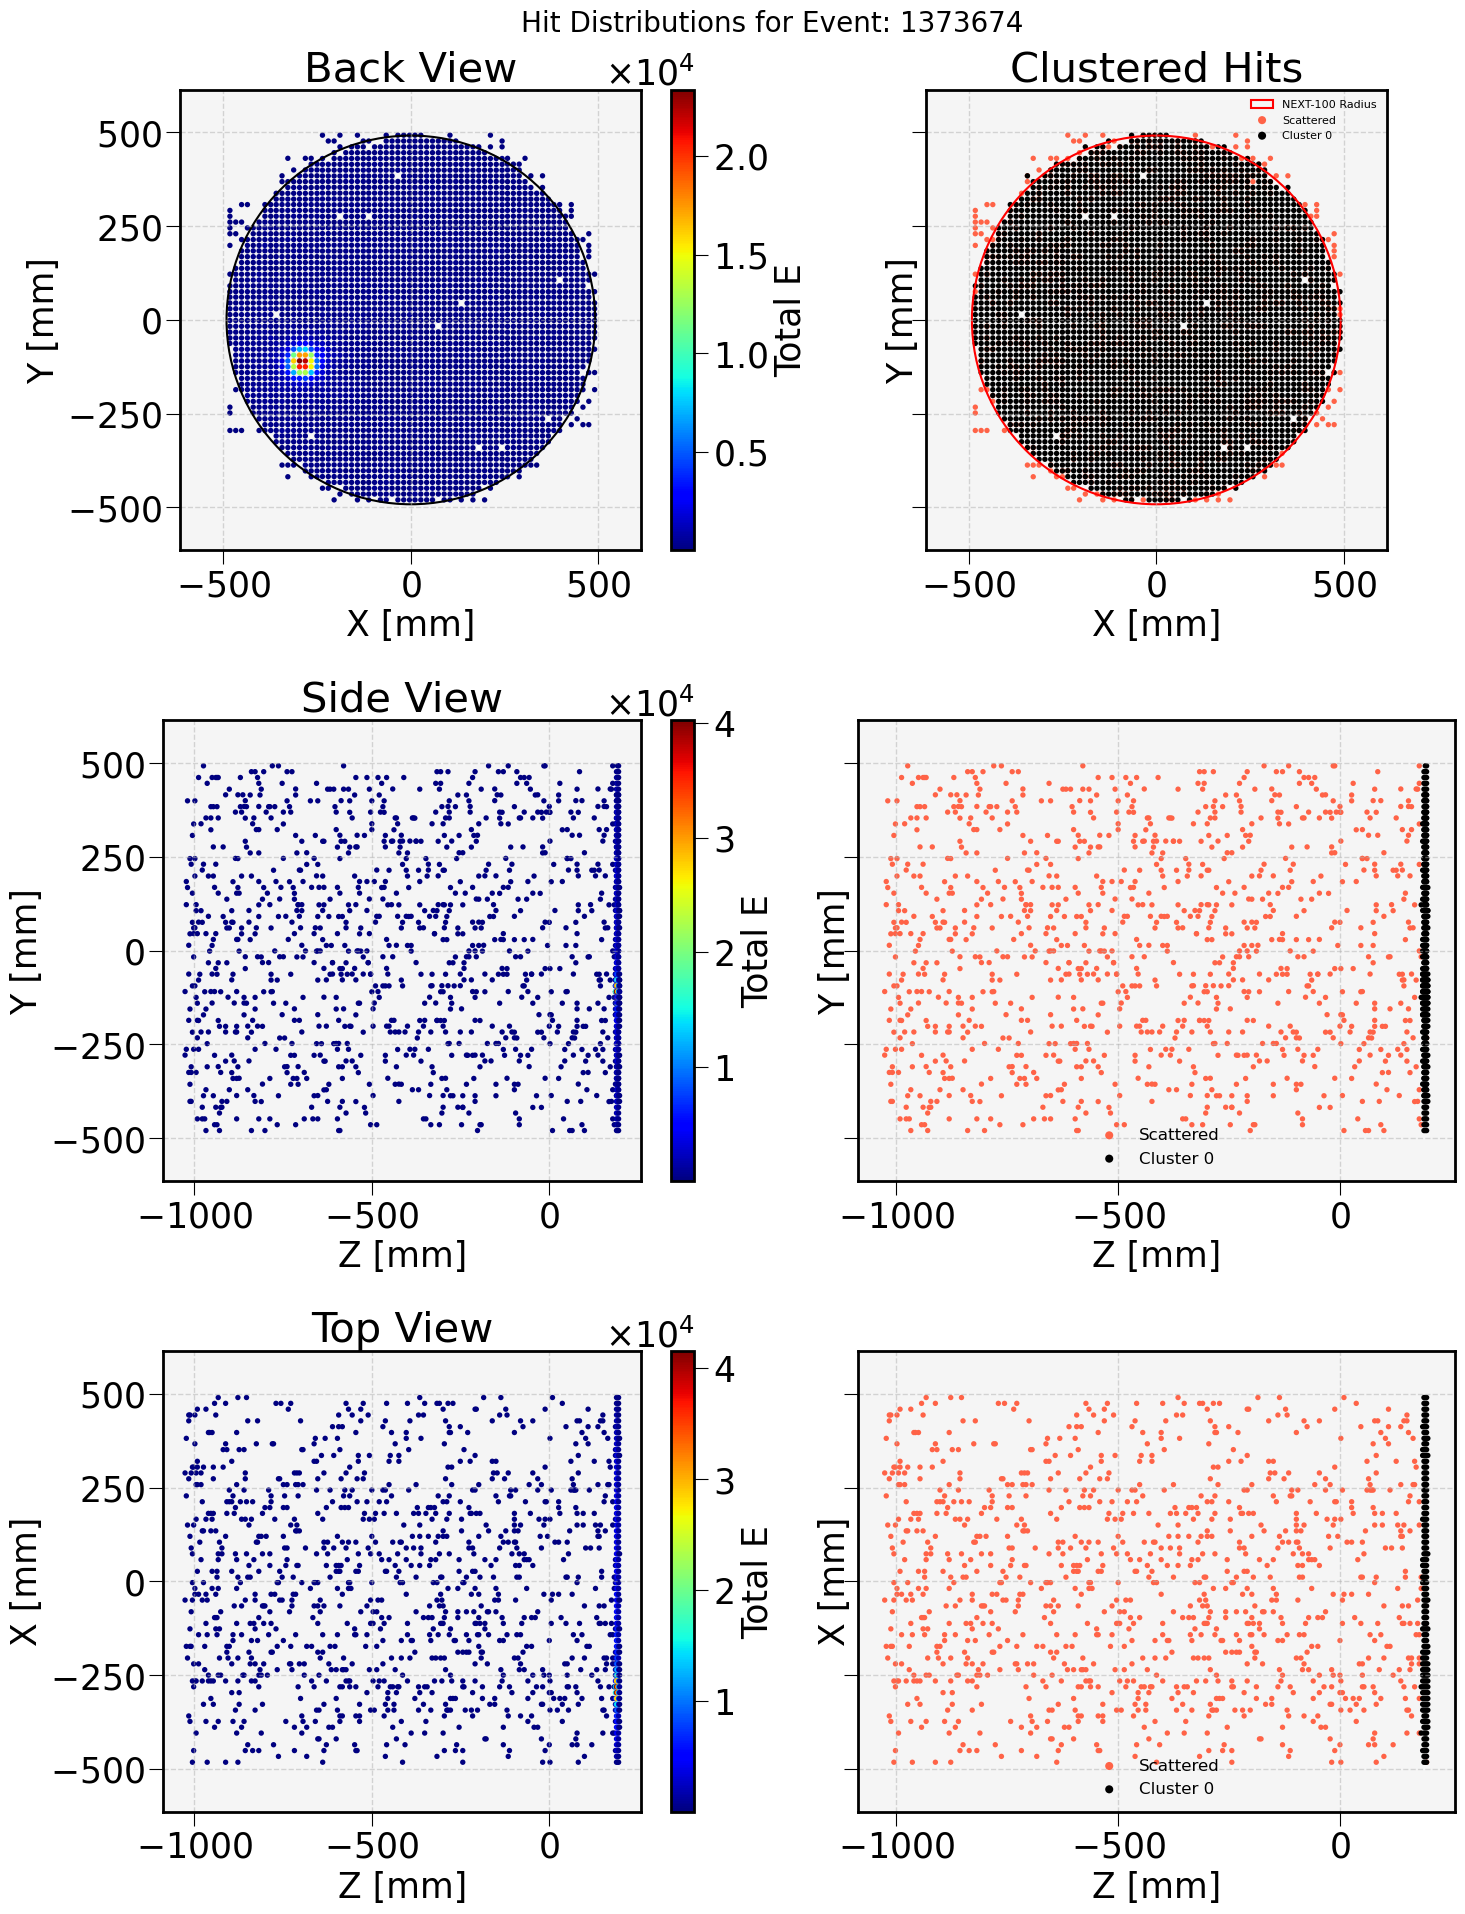

In [492]:
# Pick a random event from the clustered dataframe to visualize its hits
clust_evt_ids = df_soph['event'].unique()

# Event information + visualization
evt_test_id = np.random.choice(clust_evt_ids)
print(f"Event {evt_test_id}:")
crudo.pt.display_event_cluster(df_soph, variable='E', event=evt_test_id)

#### Energy re-distribution

In [11]:
clean_soph_df = crudo.tf.deal_spurious_hits(df_soph, energy_column='E', output_column='E_hit_pe')
print(f"After cleaning spurious hits: {clean_soph_df['event'].nunique()} events.")

# Identify events that had only spurious hits and were removed
dead_evts = set(df_soph['event'].unique()) - set(clean_soph_df['event'].unique())
print(f"Removed {len(dead_evts)} events that had only spurious hits: {dead_evts}")

After cleaning spurious hits: 4203 events.
Removed 1 events that had only spurious hits: {1533106}


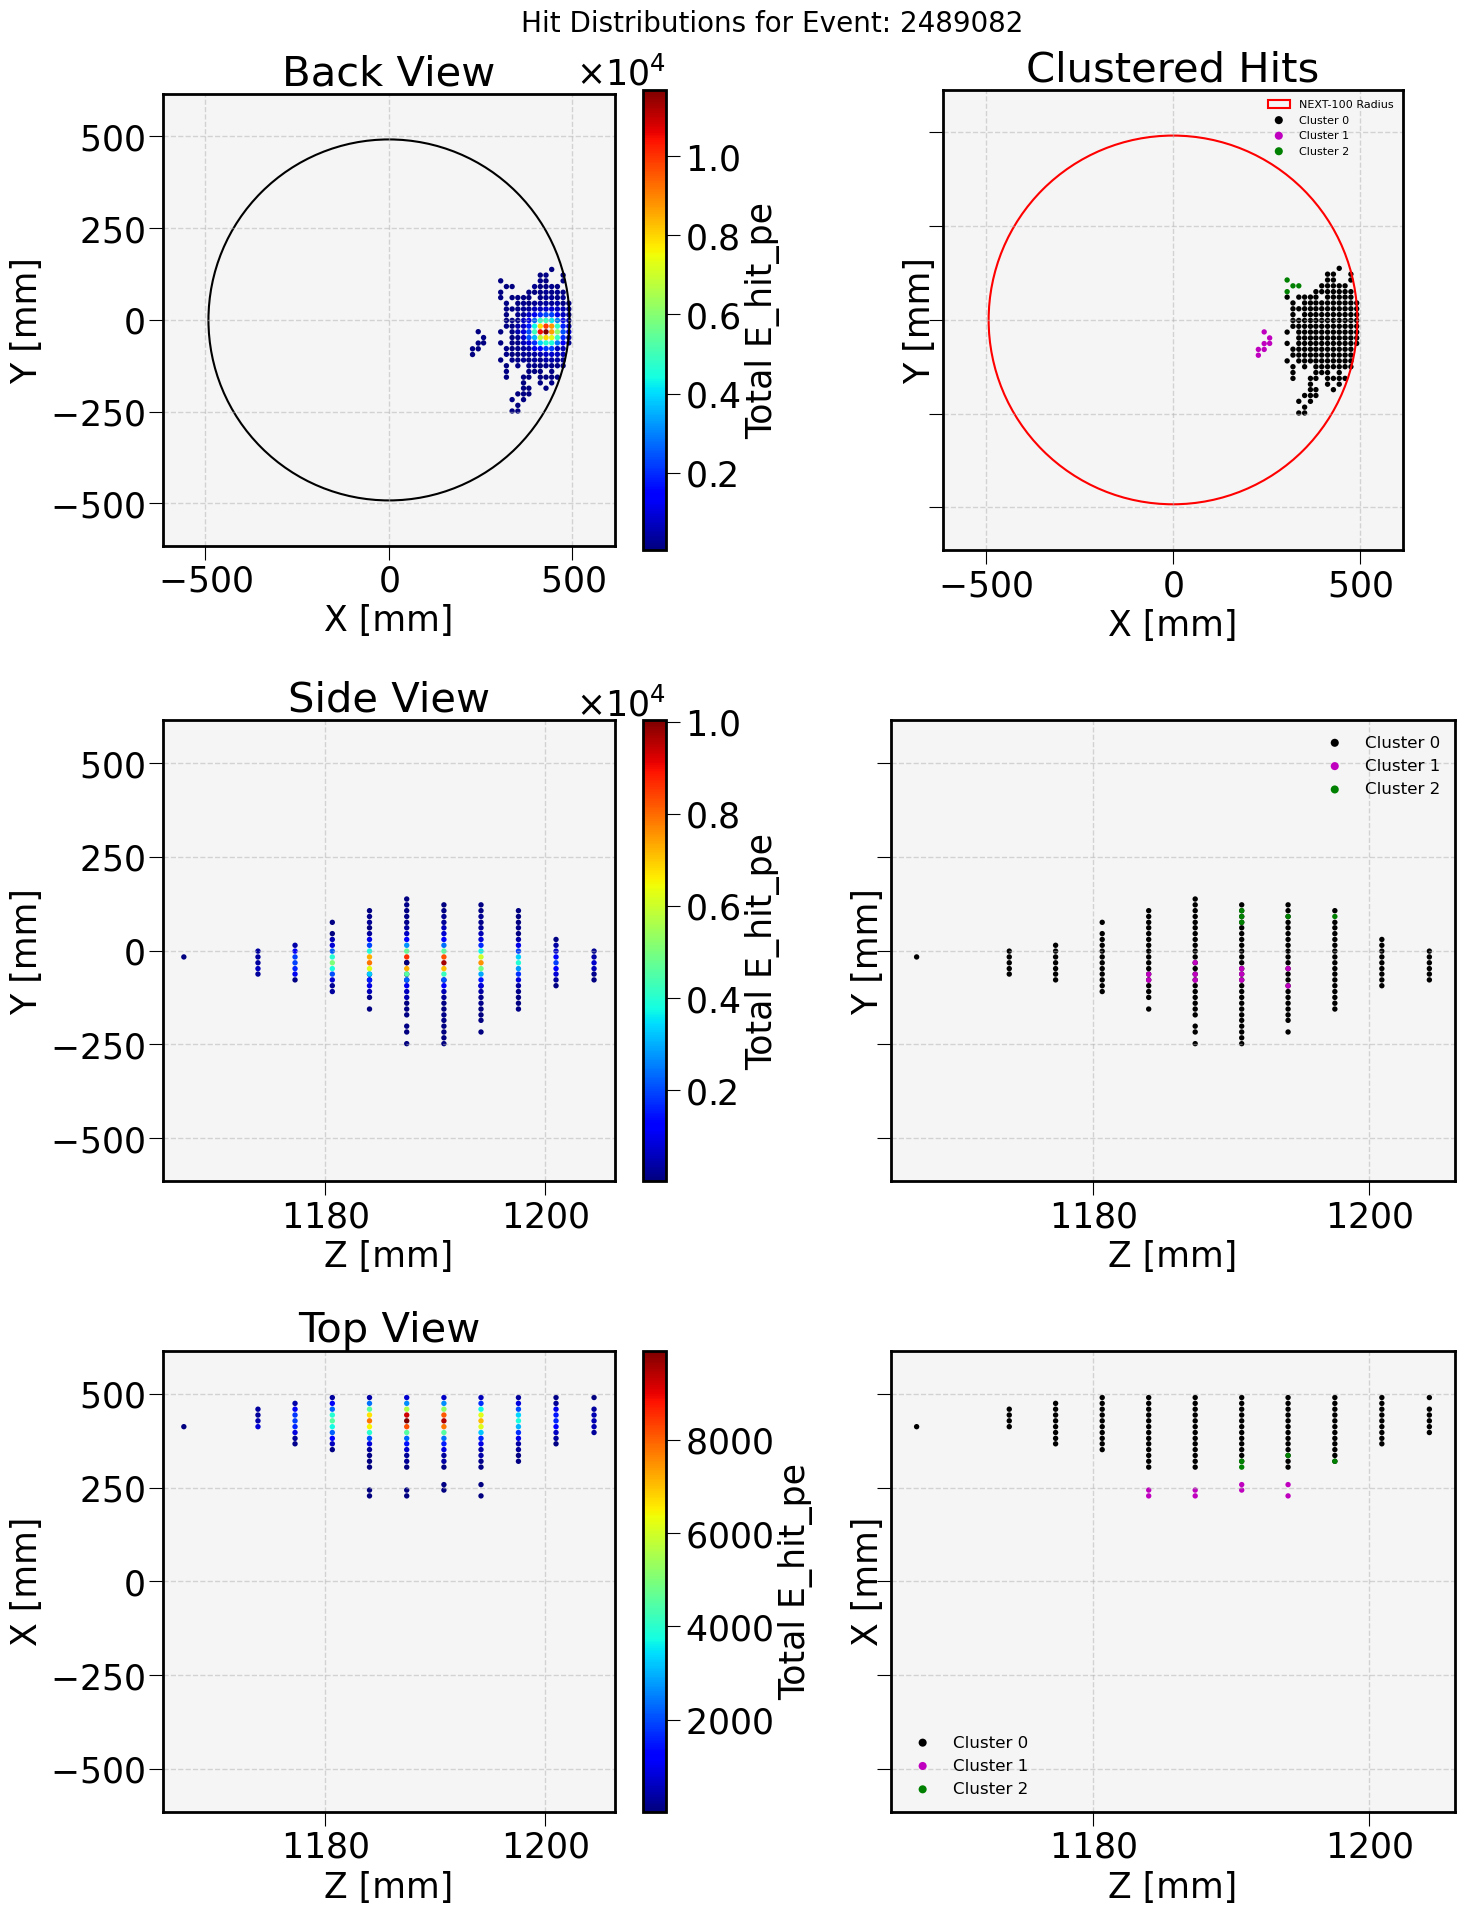

In [28]:
crudo.pt.display_event_cluster(clean_soph_df, variable='E_hit_pe', event=evt_test_id)

In the end, this clean topology is artificial, it depends on the parameters of the clusterizer function.
<br>
I deeem storing the hit size of each event is important, ~~but should be taken from the _original_ Sophronia dataframe.~~

In [29]:
# Hits per event
og_evt_size_df    = df_doro.groupby('event')['old_n_hits'].first().rename('n_hits').reset_index()
clean_evt_size_df = clean_soph_df.groupby('event').size().rename('n_hits').reset_index()

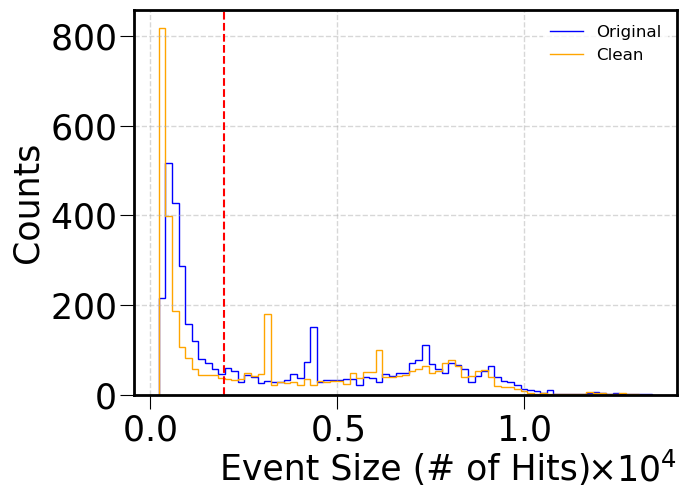

In [30]:
# Histogram
og_hits_counts, edges = np.histogram(og_evt_size_df['n_hits'], bins=75)
cl_hits_counts, _     = np.histogram(clean_evt_size_df['n_hits'], bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(og_hits_counts, edges, fill=False, ec='blue', lw=1.0, label='Original')
plt.stairs(cl_hits_counts, edges, fill=False, ec='orange', lw=1.0, label='Clean')
# Possible hit size cut
plt.axvline(x=SIZE_THRESHOLD, color='red', ls='--', lw=1.5)

# Styling
plt.xlabel('Event Size (# of Hits)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In any case, it is hard to trust in this variable. It suffers the same effect as energy event.
<br>
Some degraded alphas may have lower number of hits (~ electron size).
<br>
Although, this information together with the energies can help us a lot with tagging alpha/electron-like events. So,  I prefer to store the variable from both old and clean Sophronia.

#### Update

In [31]:
# Stay just with (updated) Sophronia dataframe
df_soph = clean_soph_df.copy()
# Update both dataframes
after_hits_treatment_ids = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_hits_treatment_ids)
print(f"After dealing with spurious hits: {df_soph['event'].nunique()} events.")

After dealing with spurious hits: 4203 events.


### Removing $Z\leq0$

Remove every event that has hits with negative $Z$ position.
<br>
This is done in Sophronia, although you will find that for some events that passed the Sophronia filter, some $[S1,\,S2]$ peak combinations may still have negative $Z$ value in Dorothea.
<br>
Due to the unsyncronized peak tagging in both dataframes, we must accept these peak combinations in Dorothea. <span style="color:red">??? NO ENTIENDO ESTO</span>

---
__UPDATE:__ As soon as we have again waveforms, we check this guys!

#### Negative events

In [43]:
events_with_negative_z_hits = df_soph.loc[df_soph['Z'] < 0, 'event'].unique()
Z_neg_doro_df, Z_neg_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_negative_z_hits)
Z_neg_soph_df

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
274587,64037,1.758898e+09,17,17.736567,8.855577,1,412.275,-78.125,0.0,0.0,-264.681438,7.121730,166.580780,-1.0,0.000922,-1,-1.0,-228.949443,0,181.670724
274588,64037,1.758898e+09,17,17.736567,8.855577,1,427.825,-78.125,0.0,0.0,-264.681438,7.251994,169.627726,-1.0,0.000959,-1,-1.0,-228.949443,0,184.993682
274589,64037,1.758898e+09,17,17.736567,8.855577,1,427.825,-62.575,0.0,0.0,-264.681438,13.016953,304.472951,-1.0,0.001718,-1,-1.0,-228.949443,0,332.054043
274590,64037,1.758898e+09,17,17.736567,8.855577,1,443.375,-78.125,0.0,0.0,-264.681438,16.131676,377.327866,-1.0,0.002334,-1,-1.0,-228.949443,0,411.508618
274591,64037,1.758898e+09,17,17.736567,8.855577,1,443.375,-62.575,0.0,0.0,-264.681438,18.270586,427.358035,-1.0,0.002620,-1,-1.0,-228.949443,0,466.070837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13620626,3005759,1.758983e+09,28,-55.791318,-155.357899,1,-126.975,-386.625,0.0,0.0,239.172125,21.283276,119.697908,-1.0,0.000700,-1,-1.0,206.883888,2,128.544617
13620627,3005759,1.758983e+09,28,-55.791318,-155.357899,1,-112.425,-417.725,0.0,0.0,239.172125,16.570955,93.195649,-1.0,0.000572,-1,-1.0,206.883888,2,100.083612
13620628,3005759,1.758983e+09,28,-55.791318,-155.357899,1,-112.425,-402.175,0.0,0.0,239.172125,16.066950,90.361104,-1.0,0.000542,-1,-1.0,206.883888,2,97.039570
13620629,3005759,1.758983e+09,28,-55.791318,-155.357899,1,-112.425,-386.625,0.0,0.0,239.172125,14.849719,83.515354,-1.0,0.000484,-1,-1.0,206.883888,2,89.687860


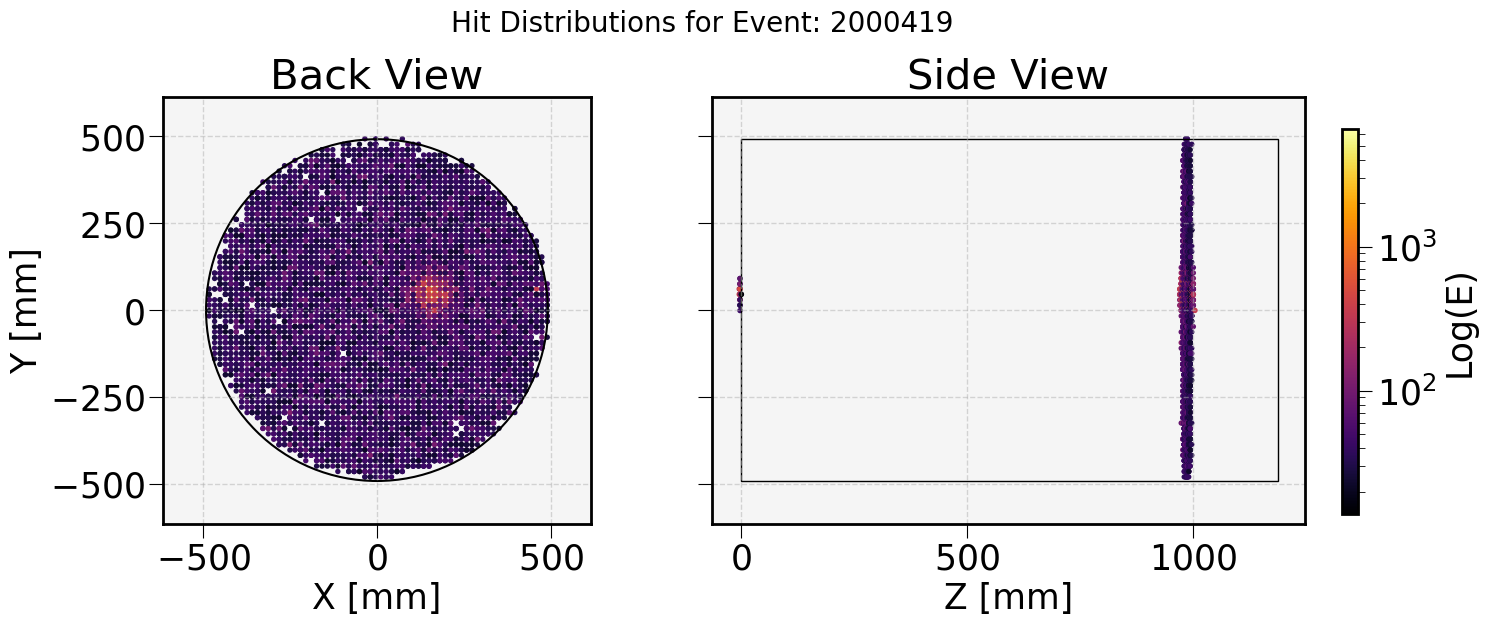

In [79]:
crudo.pt.event_display(Z_neg_soph_df, variable='E', event_column='event', event=None)

#### Positive events

In [80]:
events_with_positive_z_hits = np.setdiff1d(after_hits_treatment_ids, events_with_negative_z_hits)
Z_pos_doro_df, Z_pos_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_positive_z_hits)

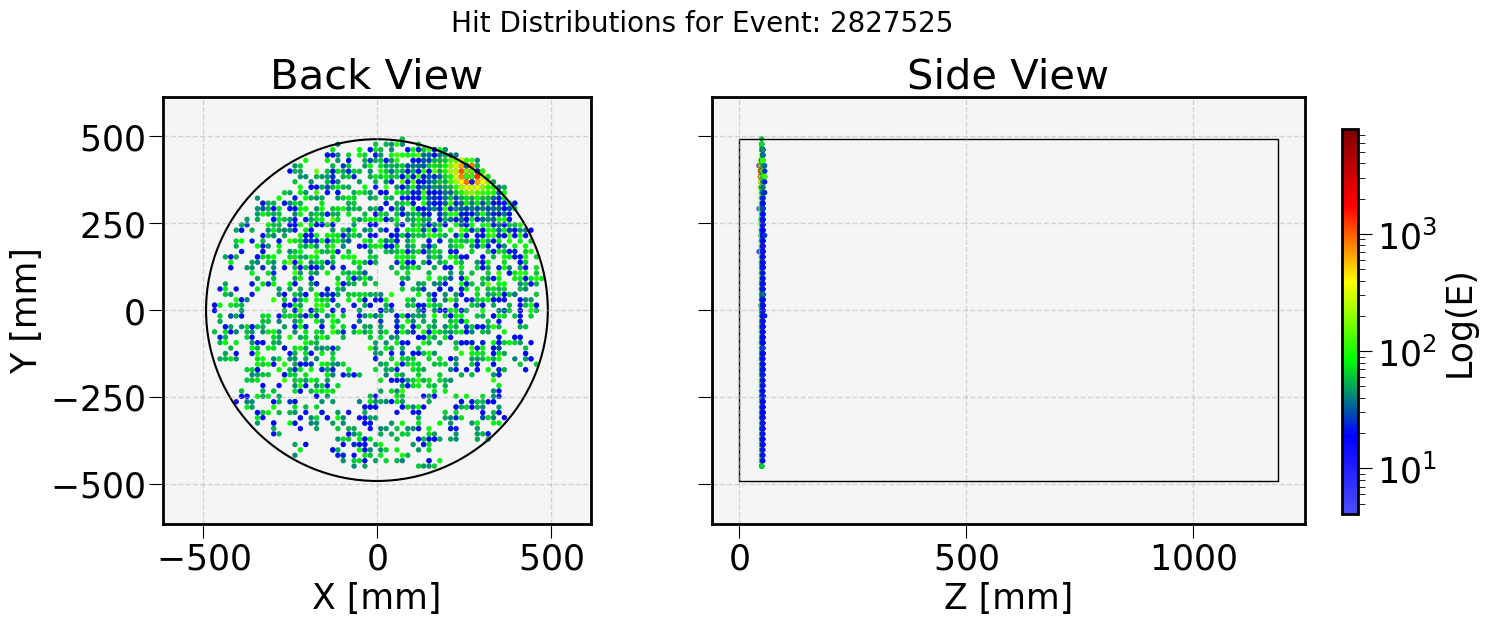

In [174]:
crudo.pt.event_display(Z_pos_soph_df, variable='E', event_column='event', event=None)

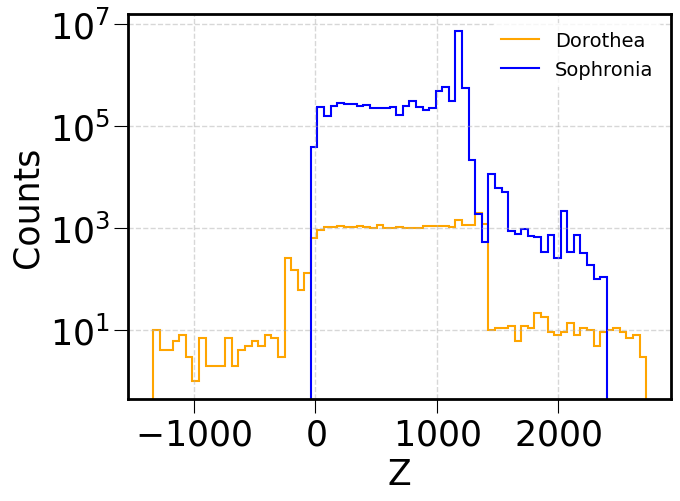

In [175]:
# Drop NaN values from the 'Z' column before creating histograms
Z_doro_clean = Z_pos_doro_df['Z'].dropna()      # nS1 = 0 has NaN Z values
Z_soph_clean = Z_pos_soph_df['Z'].dropna()

# Binning
Z_doro, edges = np.histogram(Z_doro_clean, bins=75)
Z_soph, _     = np.histogram(Z_soph_clean, bins=edges)

plt.figure(figsize=(7, 5))
plt.stairs(Z_doro, edges, fill=False, ec='orange', lw=1.5, label='Dorothea')
plt.stairs(Z_soph, edges, fill=False, ec='blue', lw=1.5, label='Sophronia')
plt.xlabel('Z')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

In [176]:
df_doro = Z_pos_doro_df.copy()
df_soph = Z_pos_soph_df.copy()
print(f"After removing events with hits at negative Z: {df_soph['event'].nunique()} events.")

After removing events with hits at negative Z: 4151 events.


### Energy Correction

Correction value @ center of anode: [0.96895808]


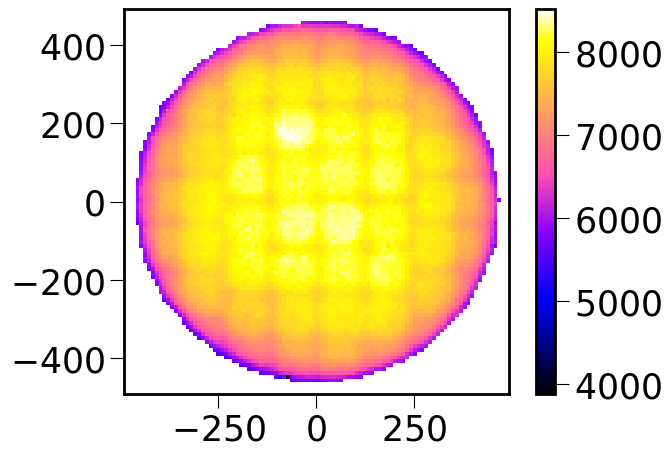

In [177]:
# Select the Kr file you want to use
# kr_test_path = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15546_15557_zemrude_map.h5'
# kr_test_path = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/h5/combined_15730_15737_zemrude_map.h5'
# kr_test_path = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/h5/krmap_3D_15737.h5'
kr_test_path = KR_PATH

# Kr map loading
kr_map_df = pd.read_hdf(kr_test_path, key='krmap/krmap')    # 'krmap/krmap' or just 'krmap'

# Check the map in the anode region (k=0)
zem_map = kr_map_df[kr_map_df['k'] == 0].copy()
plt.figure(figsize=(7, 5))
plt.imshow(zem_map['mu'].values.reshape(100, 100).T, origin='lower', extent=(-crudo.pt.N100_rad, crudo.pt.N100_rad,-crudo.pt.N100_rad, crudo.pt.N100_rad))
plt.colorbar()

corr3d = crudo.ef.get_corr3d(kr_test_path, norm_method=NormMethod.median_anode)     # If this fails look at the used key in the function
print(f'Correction value @ center of anode: {corr3d([0], [0], [0])}')

In [178]:
# How is the time evolution of energy scale?
kr_time_df = pd.read_hdf(kr_test_path, key='t_evol/t_evol')
kr_time_df.ts.value_counts()

1758896101    1
1758903301    1
1758910501    1
1758917701    1
1758924901    1
1758932101    1
1758939301    1
1758946501    1
1758953701    1
1758960901    1
1758968101    1
1758975301    1
1758982501    1
Name: ts, dtype: int64

#### Apply $^{83\text{m}}\text{Kr}$ correction

In [179]:
df_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
0,729,1.758896e+09,0,70.205942,5.904926,1,-235.825,353.775,0.0,0.0,1399.086269,5.810370,268.245727,-1.0,0.001678,-1,-1.0,1210.209623,0,268.440656
1,729,1.758896e+09,0,70.205942,5.904926,1,-112.425,-417.725,0.0,0.0,1399.086269,5.485558,253.250183,-1.0,0.001634,-1,-1.0,1210.209623,0,253.434214
2,729,1.758896e+09,0,70.205942,5.904926,1,181.025,122.525,0.0,0.0,1399.086269,6.172557,284.966708,-1.0,0.001525,-1,-1.0,1210.209623,0,285.173787
3,729,1.758896e+09,0,70.205942,5.904926,1,-373.775,-279.275,0.0,0.0,1402.239644,7.429824,156.612494,-1.0,0.001241,-1,-1.0,1212.937292,0,156.726300
4,729,1.758896e+09,0,70.205942,5.904926,1,-389.325,-93.675,0.0,0.0,1402.239644,6.564920,138.381264,-1.0,0.000797,-1,-1.0,1212.937292,0,138.481822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13672463,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,214.325,0.0,0.0,1368.305500,7.229555,6.293980,-1.0,0.000043,-1,-1.0,1183.584257,0,6.294388
13672464,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,229.875,0.0,0.0,1368.305500,7.330564,6.381917,-1.0,0.000046,-1,-1.0,1183.584257,0,6.382331
13672465,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,245.425,0.0,0.0,1368.305500,6.875893,5.986085,-1.0,0.000046,-1,-1.0,1183.584257,0,5.986474
13672466,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,260.975,0.0,0.0,1368.305500,10.088025,8.782536,-1.0,0.000077,-1,-1.0,1183.584257,0,8.783106


In [182]:
# Apply Kr correction & clean negative/NaN values
corr_soph = crudo.ef.correct_energy_by_kr_map( df_soph
                                             , kr_test_path
                                             , norm_method = NormMethod.median_anode
                                             , city = KR_CITY
                                             , mev_units  = True
                                             , energy_col = 'E_hit_pe'
                                             , output_col = 'Ec' )

corr_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
0,729,1.758896e+09,0,70.205942,5.904926,1,-235.825,353.775,0.0,0.0,1399.086269,5.810370,268.245727,-1.0,0.001667,-1,-1.0,1210.209623,0,268.440656
1,729,1.758896e+09,0,70.205942,5.904926,1,-112.425,-417.725,0.0,0.0,1399.086269,5.485558,253.250183,-1.0,0.001673,-1,-1.0,1210.209623,0,253.434214
2,729,1.758896e+09,0,70.205942,5.904926,1,181.025,122.525,0.0,0.0,1399.086269,6.172557,284.966708,-1.0,0.001512,-1,-1.0,1210.209623,0,285.173787
3,729,1.758896e+09,0,70.205942,5.904926,1,-373.775,-279.275,0.0,0.0,1402.239644,7.429824,156.612494,-1.0,0.001004,-1,-1.0,1212.937292,0,156.726300
4,729,1.758896e+09,0,70.205942,5.904926,1,-389.325,-93.675,0.0,0.0,1402.239644,6.564920,138.381264,-1.0,0.000795,-1,-1.0,1212.937292,0,138.481822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13672463,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,214.325,0.0,0.0,1368.305500,7.229555,6.293980,-1.0,0.000041,-1,-1.0,1183.584257,0,6.294388
13672464,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,229.875,0.0,0.0,1368.305500,7.330564,6.381917,-1.0,0.000041,-1,-1.0,1183.584257,0,6.382331
13672465,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,245.425,0.0,0.0,1368.305500,6.875893,5.986085,-1.0,0.000039,-1,-1.0,1183.584257,0,5.986474
13672466,3014236,1.758983e+09,0,-35.299180,44.304110,1,396.725,260.975,0.0,0.0,1368.305500,10.088025,8.782536,-1.0,0.000057,-1,-1.0,1183.584257,0,8.783106


What does the corrected energy spectrum look like now?

In [183]:
# Dataframe with energy per peak per event
event_df = corr_soph.groupby(['event']).agg(
                                                # Uncorrected
                                                X = ('X', lambda x: crudo.ut.weighted_avg(x, corr_soph.loc[x.index, 'E_hit_pe'])),
                                                Y = ('Y', lambda y: crudo.ut.weighted_avg(y, corr_soph.loc[y.index, 'E_hit_pe'])),
                                                Z = ('Z', lambda z: crudo.ut.weighted_avg(z, corr_soph.loc[z.index, 'E_hit_pe'])),
                                                E_evt = ('E_hit_pe', 'sum'), 
                                                # Corrected
                                                Xc = ('X', lambda x: crudo.ut.weighted_avg(x, corr_soph.loc[x.index, 'Ec'])),
                                                Yc = ('Y', lambda y: crudo.ut.weighted_avg(y, corr_soph.loc[y.index, 'Ec'])),
                                                Zc = ('Z', lambda z: crudo.ut.weighted_avg(z, corr_soph.loc[z.index, 'Ec'])),
                                                Ec_evt = ('Ec', 'sum')).reset_index()

event_df

,event,X,Y,Z,E_evt,Xc,Yc,Zc,Ec_evt
0,729,266.722770,-13.018567,1214.103480,523630.437398,283.411778,-14.139397,1214.084635,3.223500
1,2129,102.705459,-157.386165,1184.943757,960971.248074,102.168362,-156.682492,1184.950616,5.216170
2,2402,235.198641,15.149541,1177.730909,108823.354269,235.416304,15.217519,1177.726473,0.584186
3,2458,-360.746622,-240.124363,185.621005,207269.763765,-365.991262,-244.065839,185.602276,1.378486
4,2899,419.816401,-132.817800,290.126631,226949.963421,424.900663,-134.443156,290.116533,1.474487
...,...,...,...,...,...,...,...,...,...
4146,3011590,305.430561,-144.792333,1187.220391,627768.901346,309.230610,-146.521774,1187.221645,3.654926
4147,3012136,68.916650,231.574772,216.603525,84376.414520,68.955353,231.732198,216.597186,0.438330
4148,3012829,-420.344523,-14.513955,1186.157940,116444.200748,-421.599800,-14.890201,1186.152577,0.720343
4149,3013354,-339.679015,-295.001653,444.167896,139786.502155,-341.382196,-295.423848,444.198066,0.931099


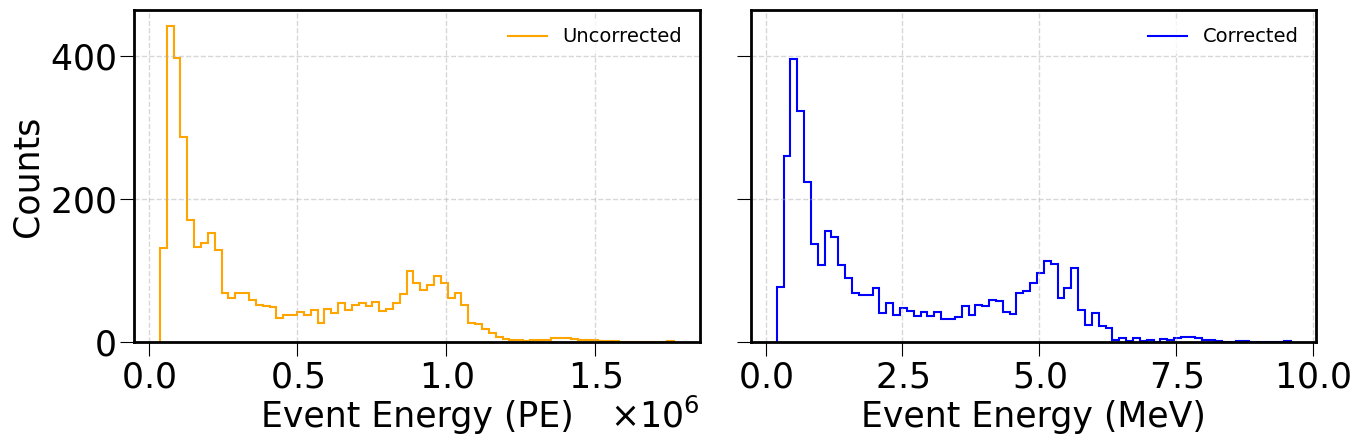

In [190]:
# Histogram
E_counts, e   = np.histogram(event_df['E_evt'], bins=75)
Ec_counts, ec = np.histogram(event_df['Ec_evt'], bins=75)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot uncorrected energy histogram
axes[0].stairs(E_counts, e, fill=False, ec='orange', lw=1.5, label='Uncorrected')
axes[0].set_xlabel('Event Energy (PE)')
axes[0].set_ylabel('Counts')
axes[0].legend(fontsize=14)
axes[0].grid(True)

# Plot corrected energy histogram
axes[1].stairs(Ec_counts, ec, fill=False, ec='blue', lw=1.5, label='Corrected')
axes[1].set_xlabel('Event Energy (MeV)')
axes[1].legend(fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

__NOTE:__ I must think in a good ando direct way to check the correction in the dataset.

ValueError: Normalization failed: Center bin value is zero.

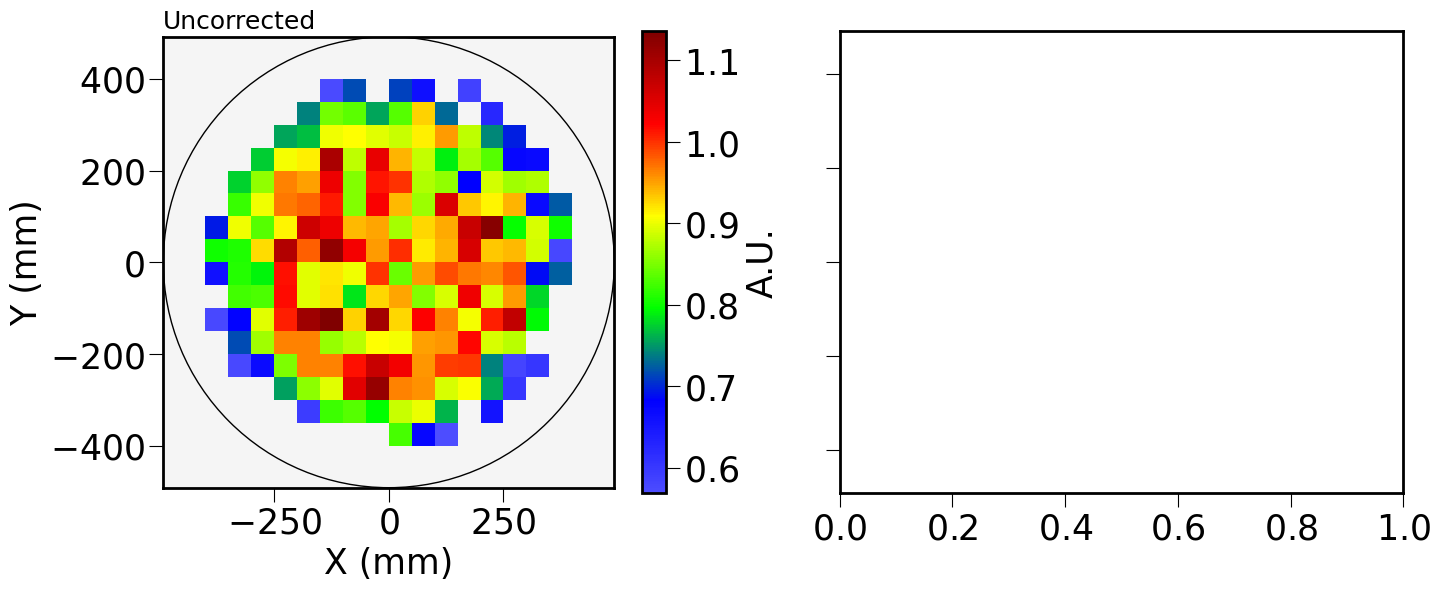

In [191]:
# Global
n_bins = 25
masking = True

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for i, data in enumerate(['Uncorrected', 'Corrected']):

    if data == 'Uncorrected':
        X = event_df['X'];  Y = event_df['Y']
        Z = event_df['Z'];  E = event_df['E_evt']
    elif data == 'Corrected':
        X = event_df['Xc']; Y = event_df['Yc']
        Z = event_df['Zc']; E = event_df['Ec_evt']

    # Masking
    if masking:
        time_mask = (Z > 1150)  # Cathode
        energy_mask = (0.5e6 <= E) & (E <= 2e6) # Alphas
        X = X[time_mask & energy_mask];  Y = Y[time_mask & energy_mask]
        Z = Z[time_mask & energy_mask];  E = E[time_mask & energy_mask]

    # XY map
    S2e_XY_map, x_edges, y_edges = crudo.pt.mapping(X, Y, wei=E, xy_bins=n_bins, norm=True)
    S2e_XY_map                   = np.ma.masked_where(S2e_XY_map == 0, S2e_XY_map)
    # Mask values outside the range [0, 2] in the Z-axis
    # S2e_XY_map = np.ma.masked_outside(S2e_XY_map, 0.8, 1.2)

    # Plot
    pcm = axes[i].pcolormesh(x_edges, y_edges, S2e_XY_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = fig.colorbar(pcm, ax=axes[i], label='A.U.')
    axes[i].set_xlabel('X (mm)')
    axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_ylabel('Y (mm)')
    axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
    axes[i].set_title(data, fontsize=18, loc='left')

    axes[i].set_aspect('equal', adjustable='box')
    axes[i].set_facecolor('whitesmoke')
    axes[i].add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))

plt.tight_layout()
plt.show()

In [14]:
# # Global
# n_bins = 40
# masking = True

# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
# for i, (energy, label) in enumerate(zip(['E', 'E_corr_pe'], ['Unc. Energy', 'Kr-Corr. Energy'])):

#     # Variables
#     X = corr_soph['X'];   Y  = corr_soph['Y']
#     Z = corr_soph['Z'];   DT = corr_soph['DT']
#     E = corr_soph[energy]

#     # Masking
#     if masking:
#         time_mask = (DT > 0.9*DT_CATH)
#         X = X[time_mask];  Y = Y[time_mask]
#         Z = Z[time_mask];  E = E[time_mask]

#     # XY map
#     S2e_XY_map, x_edges, y_edges = crudo.pt.mapping(X, Y, wei=E, xy_bins=n_bins, norm=True)
#     S2e_XY_map                   = np.ma.masked_where(S2e_XY_map == 0, S2e_XY_map)
#     # Mask values outside the range [0, 2] in the Z-axis
#     # S2e_XY_map = np.ma.masked_outside(S2e_XY_map, 0, 2)

#     # Plot
#     pcm = axes[i].pcolormesh(x_edges, y_edges, S2e_XY_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
#     cbar = fig.colorbar(pcm, ax=axes[i], label='Factor')
#     axes[i].set_xlabel('X (mm)')
#     axes[i].set_xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
#     axes[i].set_ylabel('Y (mm)')
#     axes[i].set_ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
#     axes[i].set_title(label, fontsize=18, loc='left')

#     axes[i].set_aspect('equal', adjustable='box')
#     axes[i].set_facecolor('whitesmoke')
#     axes[i].add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))

# plt.tight_layout()
# plt.show()

#### Update

In [192]:
# New dataframe with corrected energy per hit
df_soph = corr_soph.copy()

after_energy_correction_ids = df_soph['event'].unique()
df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=after_energy_correction_ids)
print(f"After Kr energy correction: {df_soph['event'].nunique()} events.")

After Kr energy correction: 4151 events.


### $S1e$ Cut & Correction

#### $nS1\,\leq\,1$ (NO-Polike)

In [200]:
s1_mask = (df_doro['nS1'] == 0) | ((df_doro['nS1'] == 1) & (df_doro['S1h'] >= M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE))
S1_doro_df, S1_soph_df = crudo.dm.apply_cut_and_update(df_doro, df_soph, cut_mask=s1_mask, df_for_mask=df_doro)

In [201]:
S1_doro_df['nS1'].value_counts()

1    2795
0     372
Name: nS1, dtype: int64

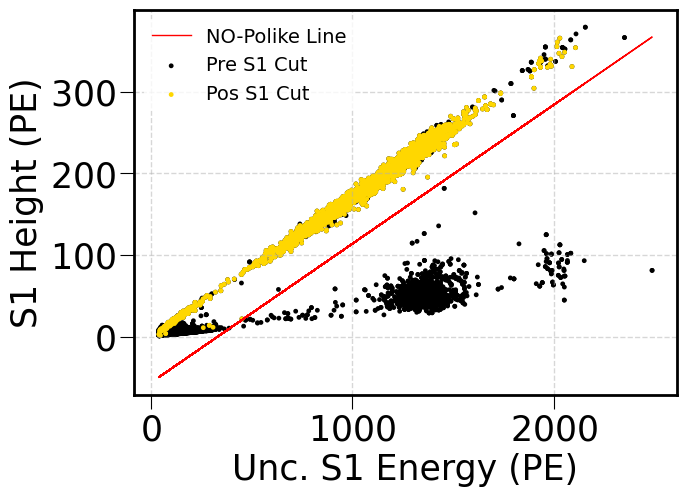

In [202]:
plt.figure(figsize=(7, 5))
plt.scatter(df_doro['S1e'], df_doro['S1h'], s=12, c='black', ec='none', label='Pre S1 Cut')
plt.scatter(S1_doro_df['S1e'], S1_doro_df['S1h'], s=12, c='gold', ec='none', label='Pos S1 Cut')
plt.plot(df_doro['S1e'], M_NOPOLIKE * df_doro['S1e'] + B_NOPOLIKE, c='red', ls='-', lw=1.0, label='NO-Polike Line')
plt.xlabel('Unc. S1 Energy (PE)')
plt.ylabel('S1 Height (PE)')
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

#### $S1e$ correction

In [204]:
S1_corr_doro_df = crudo.ef.correct_S1e(S1_doro_df, CV_FIT, DT_CATH, output_column='S1e_corr')     # Based on alpha analysis

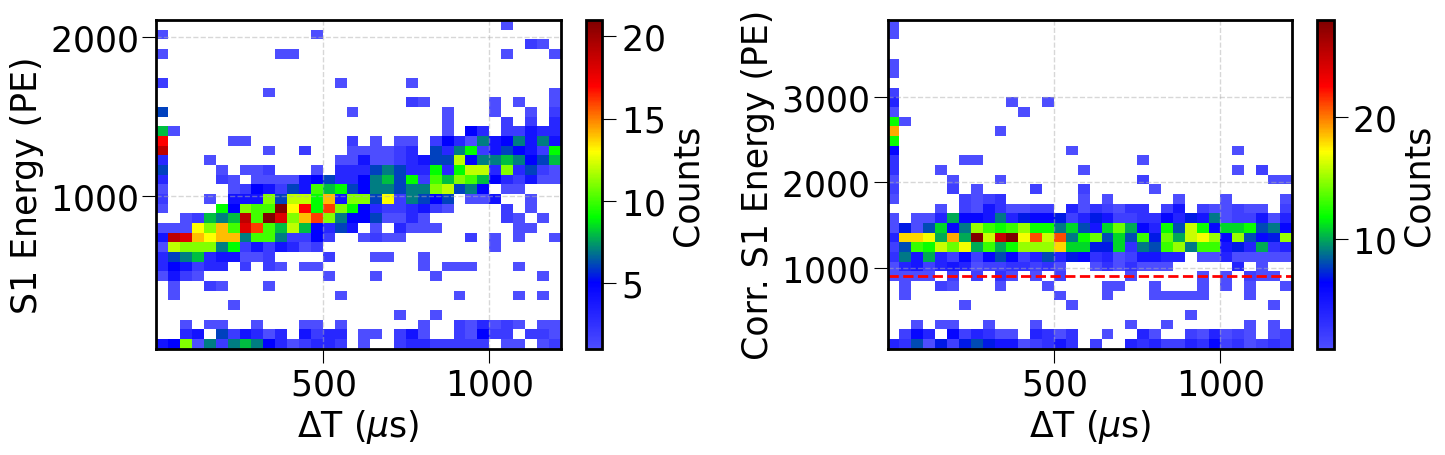

In [208]:
n_bins = 35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(['S1e', 'S1e_corr']):

    # Variables
    E1 = S1_corr_doro_df[col]
    DT = S1_corr_doro_df['DT']
    R = np.sqrt(S1_corr_doro_df['X']**2 + S1_corr_doro_df['Y']**2)

    # Masking
    rad_mask  = (R  < R_UP)
    time_mask = (DT >= 0) & (DT < 0.9*DT_CATH)
    E1 = E1[rad_mask & time_mask]
    DT = DT[rad_mask & time_mask]

    # 2D histogram
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT, E1, x_bins=n_bins, y_bins=n_bins)
    S1e_DT_map = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)

    im = axes[i].pcolormesh(ex, ey, S1e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(im, ax=axes[i], label='Counts', shrink=1.0)
    axes[i].set_xlabel('$\Delta$T ($\mu$s)')
    axes[i].set_ylabel('Corr. S1 Energy (PE)' if col == 'S1e_corr' else 'S1 Energy (PE)')
    axes[i].grid(True)

    # Possible alpha/electron limit line
    if col == 'S1e_corr':
        axes[i].axhline(y=S1_ENERGY_THRESHOLD, color='red', ls='--')

plt.tight_layout()
plt.show()

Max. corrected $S1$ energy per event would be our main discriminator for alpha/electron tagging!
<br>
In particular, for events with bad energy $(S2)$ reconstruction (~ cathode region, where we have degraded alphas).

In [215]:
df_doro = S1_corr_doro_df.copy()
df_soph = S1_soph_df.copy()

print(f"After S1 cut & correction: {df_soph['event'].nunique()} events.")

After S1 cut & correction: 2798 events.


### Data @ Event/Peak-level

#### From Dorothea

In [210]:
# df_doro.event.nunique()
df_doro

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,old_n_hits,S1e_corr
0,729,1.758896e+09,65535,0,0,1,NaN,NaN,NaN,NaN,...,NaN,141.095500,70.205941,5.904926,70.453831,0.083911,284.108575,240.892844,5050,NaN
1,2129,1.758896e+09,0,0,1,1,350.0,237.076340,1371.259766,49250.0,...,1371.233521,8.474766,78.247033,-116.241375,140.123715,-0.978324,181.564442,196.641403,8379,1360.743224
2,2402,1.758896e+09,0,0,1,1,525.0,29.957884,160.021713,52750.0,...,1361.733887,11.567513,72.104002,14.806332,73.608522,0.202531,244.880942,223.323765,886,159.341187
3,2458,1.758896e+09,0,0,1,1,650.0,118.981293,696.163391,1192325.0,...,214.165878,6.338744,-154.165612,-95.309713,181.248386,-2.587877,268.540573,235.194201,1253,1186.814015
4,2899,1.758896e+09,0,0,1,1,825.0,146.900162,863.421326,1073225.0,...,335.264008,6.771373,166.275405,-44.150231,172.037069,-0.259536,288.758860,215.460751,1421,1369.078537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31077,3010715,1.758983e+09,0,0,1,1,350.0,198.330582,1236.313354,310550.0,...,1097.940186,8.165644,-171.203779,123.162482,210.902183,2.517971,260.547455,220.067898,617,1361.195039
31078,3011457,1.758983e+09,0,0,1,1,350.0,239.161346,1369.186157,50425.0,...,1368.060791,8.443411,-54.923952,-12.641598,56.360008,-2.915367,172.804523,165.800122,8461,1360.244285
31079,3011590,1.758983e+09,0,0,1,1,625.0,167.346085,983.265747,44025.0,...,1373.459351,8.839169,214.472085,-99.563708,236.455508,-0.434622,232.297870,181.629643,4522,974.941037
31080,3012136,1.758983e+09,0,0,1,1,325.0,9.175889,58.074413,1156100.0,...,247.380264,8.245391,33.168144,99.195239,104.593601,1.248111,204.296157,229.226582,452,97.005556


In [211]:
doro_info_df = crudo.dm.summarize_dorothea_info(df_doro, event_level_cols=EVENT_LEVEL_COLS)
doro_info_df

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,540593.812500,1410.800,117027.218750,1403490.250,277555.593750
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,971646.062500,179.825,53667.812500,1420483.500,218239.109375
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,111630.500000,264.925,4925.912109,1414483.875,55677.093750
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,211339.796875,167.000,28458.962891,1406490.875,61267.597656
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,231755.187500,259.550,25652.800781,1408489.000,77634.679688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,95111.789062,125.800,5841.302246,1408490.125,33024.136719
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,999064.125000,153.700,55248.109375,1418485.750,223673.468750
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,634231.937500,135.000,35426.460938,1417484.250,150686.375000
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,85847.921875,132.000,5613.741211,1403480.250,30480.246094


In [212]:
doro_info_df.nunique()

event         2798
nS1              2
nS2              5
old_n_hits    1853
time          2798
S1e           2459
S1e_corr      2795
S1w             34
S1h           2459
S1t           2170
S2e           3167
S2w           2320
S2h           3167
S2t           1861
S2q           3167
dtype: int64

#### From Sophronia (NO spurious hits)

In [216]:
df_soph

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,DT,Q,E,Qc,Ec,track_id,Ep,Z,cluster,E_hit_pe
0,729,1.758896e+09,0,70.205942,5.904926,1,-235.825,353.775,0.0,0.0,1399.086269,5.810370,268.245727,-1.0,0.001667,-1,-1.0,1210.209623,0,268.440656
1,729,1.758896e+09,0,70.205942,5.904926,1,-112.425,-417.725,0.0,0.0,1399.086269,5.485558,253.250183,-1.0,0.001673,-1,-1.0,1210.209623,0,253.434214
2,729,1.758896e+09,0,70.205942,5.904926,1,181.025,122.525,0.0,0.0,1399.086269,6.172557,284.966708,-1.0,0.001512,-1,-1.0,1210.209623,0,285.173787
3,729,1.758896e+09,0,70.205942,5.904926,1,-373.775,-279.275,0.0,0.0,1402.239644,7.429824,156.612494,-1.0,0.001004,-1,-1.0,1212.937292,0,156.726300
4,729,1.758896e+09,0,70.205942,5.904926,1,-389.325,-93.675,0.0,0.0,1402.239644,6.564920,138.381264,-1.0,0.000795,-1,-1.0,1212.937292,0,138.481822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13666591,3013354,1.758983e+09,17,-108.014301,-83.445478,1,-359.225,-263.725,0.0,0.0,525.288500,10.851259,62.412691,-1.0,0.000415,-1,-1.0,454.374552,1,67.225969
13666592,3013354,1.758983e+09,17,-108.014301,-83.445478,1,-343.675,-294.825,0.0,0.0,525.288500,33.416073,192.197697,-1.0,0.001419,-1,-1.0,454.374552,1,207.020016
13666593,3013354,1.758983e+09,17,-108.014301,-83.445478,1,-343.675,-279.275,0.0,0.0,525.288500,25.954491,149.281256,-1.0,0.000985,-1,-1.0,454.374552,1,160.793852
13666594,3013354,1.758983e+09,17,-108.014301,-83.445478,1,-328.125,-294.825,0.0,0.0,525.288500,10.487391,60.319850,-1.0,0.000403,-1,-1.0,454.374552,1,64.971727


In [218]:
df_soph = df_soph.loc[:, FINAL_SOPH_COLUMNS].copy()
df_soph

,event,time,npeak,X,Y,DT,Z,Ec,cluster
0,729,1.758896e+09,0,-235.825,353.775,1399.086269,1210.209623,0.001667,0
1,729,1.758896e+09,0,-112.425,-417.725,1399.086269,1210.209623,0.001673,0
2,729,1.758896e+09,0,181.025,122.525,1399.086269,1210.209623,0.001512,0
3,729,1.758896e+09,0,-373.775,-279.275,1402.239644,1212.937292,0.001004,0
4,729,1.758896e+09,0,-389.325,-93.675,1402.239644,1212.937292,0.000795,0
...,...,...,...,...,...,...,...,...,...
13666591,3013354,1.758983e+09,17,-359.225,-263.725,525.288500,454.374552,0.000415,1
13666592,3013354,1.758983e+09,17,-343.675,-294.825,525.288500,454.374552,0.001419,1
13666593,3013354,1.758983e+09,17,-343.675,-279.275,525.288500,454.374552,0.000985,1
13666594,3013354,1.758983e+09,17,-328.125,-294.825,525.288500,454.374552,0.000403,1


In [219]:
soph_event_info_df = crudo.dm.summarize_hits_to_event_level(df_soph, energy_column='Ec')
soph_event_info_df

,event,E_evt,n_cluster,n_hits,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,729,3.223500,1,3845,283.411778,-14.139397,1214.084635,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397
1,2129,5.216170,1,8221,102.168362,-156.682492,1184.950616,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751
2,2402,0.584186,1,582,235.416304,15.217519,1177.726473,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133
3,2458,1.378486,30,702,-365.991262,-244.065839,185.602276,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324
4,2899,1.474487,27,817,424.900663,-134.443156,290.116533,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2793,3010715,0.605089,2,414,-368.282912,246.661787,949.141978,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490
2794,3011457,5.301890,1,8297,-71.557856,-17.384803,1183.651875,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456
2795,3011590,3.654926,21,4249,309.230610,-146.521774,1187.221645,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680
2796,3012136,0.438330,1,290,68.955353,231.732198,216.597186,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945


In [48]:
# soph_peak_info_df = df_final_soph.groupby(['event', 'npeak']).agg(E_peak_pe = ('E_hit_pe', 'sum')).reset_index()
# soph_peak_info_df

#### Aggregate

In [220]:
# df_file = pd.merge(soph_peak_info_df, soph_event_info_df, on='event', how='left')
df_file = pd.merge(doro_info_df, soph_event_info_df, on='event', how='left')
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,...,283.411778,-14.139397,1214.084635,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,...,102.168362,-156.682492,1184.950616,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,...,235.416304,15.217519,1177.726473,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,...,-365.991262,-244.065839,185.602276,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,...,424.900663,-134.443156,290.116533,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,...,-368.282912,246.661787,949.141978,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,...,-71.557856,-17.384803,1183.651875,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,...,309.230610,-146.521774,1187.221645,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,...,68.955353,231.732198,216.597186,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945


I do not put $S1$ energy @ peak-level cause' the unsyncronized tag of peaks between Dorothea and Sophronia

# Tagging

Now, with the final dataframes we can inspect the tagging of events by particle type and detector region.

## By Particle

Recall, we still have degradated alphas, so we need to establish a proper way to distinguish alphas from electrons

In [221]:
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,...,283.411778,-14.139397,1214.084635,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,...,102.168362,-156.682492,1184.950616,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,...,235.416304,15.217519,1177.726473,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,...,-365.991262,-244.065839,185.602276,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,...,424.900663,-134.443156,290.116533,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,...,-368.282912,246.661787,949.141978,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,...,-71.557856,-17.384803,1183.651875,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,...,309.230610,-146.521774,1187.221645,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,...,68.955353,231.732198,216.597186,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945


In [222]:
zero_s1_events_df = df_file[df_file['nS1'] == 0].copy()
print(f"Events with zero S1: {zero_s1_events_df['event'].nunique()} ({zero_s1_events_df['event'].nunique() / df_file['event'].nunique() :.2%})")
one_s1_events_df  = df_file[df_file['nS1'] == 1].copy()
print(f"Events with one S1: {one_s1_events_df['event'].nunique()} ({one_s1_events_df['event'].nunique() / df_file['event'].nunique() :.2%})")

Events with zero S1: 339 (12.12%)
Events with one S1: 2459 (87.88%)


Take a look to the energy spectrum

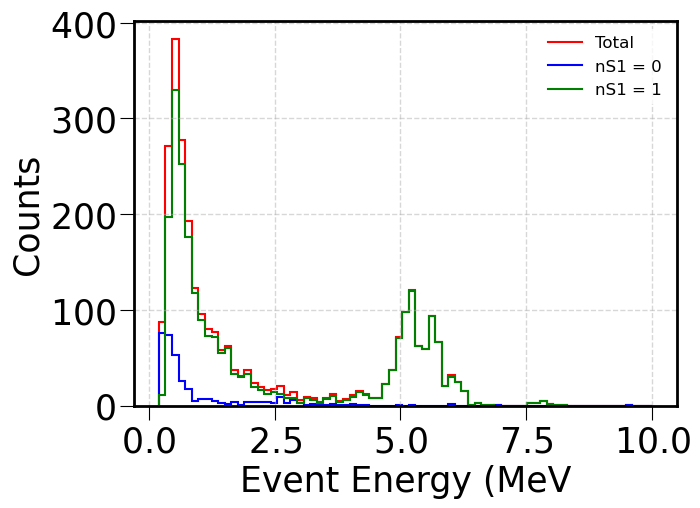

In [231]:
# Histogram
all_evt_counts, edges = np.histogram(df_file['E_evt'].unique(), bins=75, range=(df_file['E_evt'].min(), 10))
zero_s1_evt_counts, _ = np.histogram(zero_s1_events_df['E_evt'].unique(), bins=edges)
one_s1_evt_counts, _  = np.histogram(one_s1_events_df['E_evt'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(all_evt_counts, edges, fill=False, ec='red', lw=1.5, label='Total')
plt.stairs(zero_s1_evt_counts, edges, fill=False, ec='blue', lw=1.5, label='nS1 = 0')
plt.stairs(one_s1_evt_counts, edges, fill=False, ec='green', lw=1.5, label='nS1 = 1')

# Styling
plt.xlabel('Event Energy (MeV)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

### $nS1 = 0$

In this case a good discriminator would be the _event size_ (# of hits)

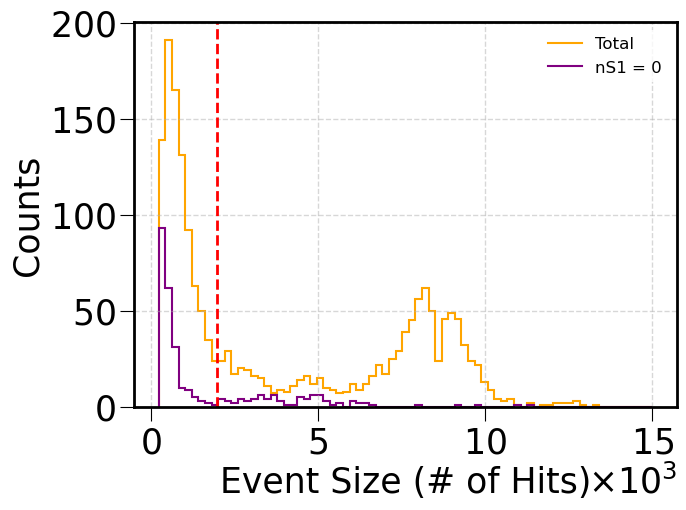

In [232]:
# Histogram
evt_counts, edges = np.histogram(df_file['old_n_hits'].unique(), bins=75, range=(df_file['old_n_hits'].min(), 15e3))
zero_s1_counts, _ = np.histogram(zero_s1_events_df['old_n_hits'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(evt_counts, edges, fill=False, ec='orange', lw=1.5, label='Total')
plt.stairs(zero_s1_counts, edges, fill=False, ec='purple', lw=1.5, label='nS1 = 0')

plt.axvline(x=SIZE_THRESHOLD, color='red', ls='--')     # Event size cut

# Styling
plt.xlabel('Event Size (# of Hits)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [234]:
zero_s1_elec_like  = zero_s1_events_df.loc[zero_s1_events_df['old_n_hits'] <= SIZE_THRESHOLD, 'event'].unique()
zero_s1_alpha_like = zero_s1_events_df.loc[zero_s1_events_df['old_n_hits'] >  SIZE_THRESHOLD, 'event'].unique()
print(f"Number of electron-like events: {len(zero_s1_elec_like)} ({len(zero_s1_elec_like) / zero_s1_events_df['event'].nunique() :.2%})")
print(f"Number of alpha-like events: {len(zero_s1_alpha_like)} ({len(zero_s1_alpha_like) / zero_s1_events_df['event'].nunique() :.2%})")

Number of electron-like events: 258 (76.11%)
Number of alpha-like events: 81 (23.89%)


Take a look to some event displays

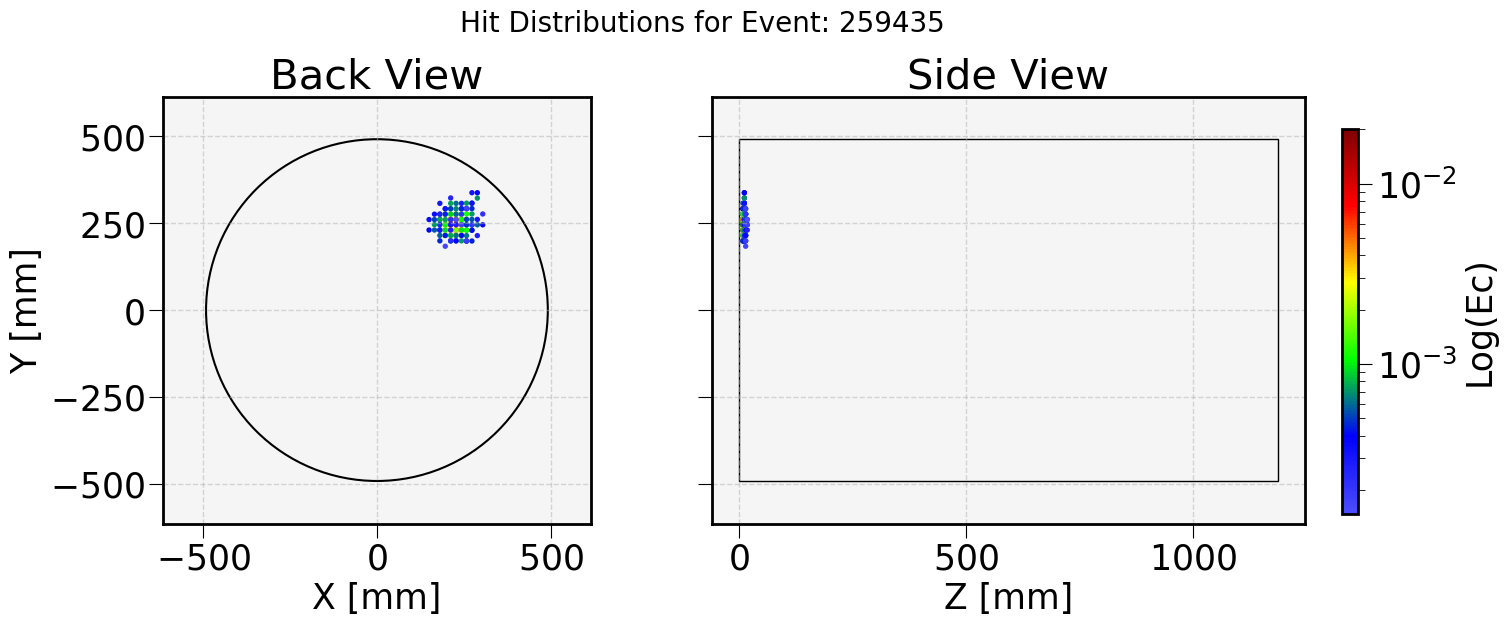

In [265]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(zero_s1_elec_like))

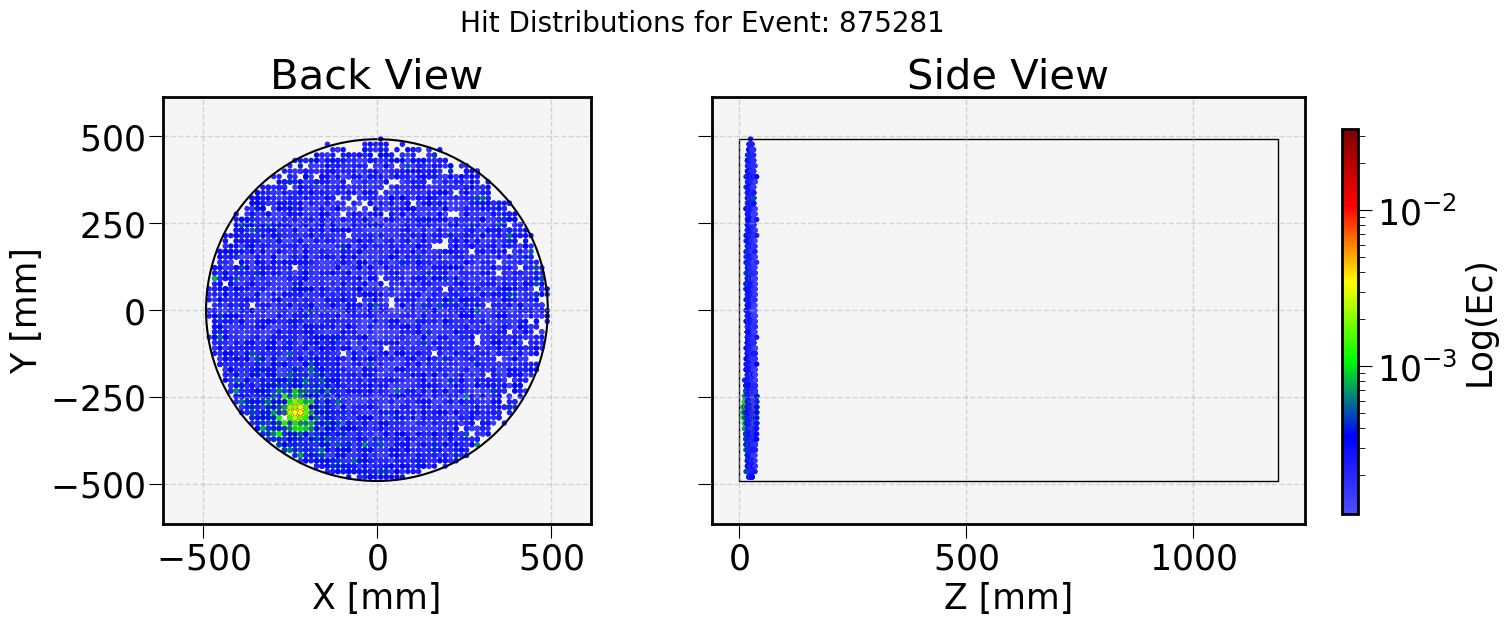

In [271]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(zero_s1_alpha_like))

### $nS1 = 1$

Here, the discriminator is the _corrected S1 energy_!
AQUÍ EL TAGGER FUNCIONA CON LA MÁX!

In [272]:
df_file.columns

Index(['event', 'nS1', 'nS2', 'old_n_hits', 'time', 'S1e', 'S1e_corr', 'S1w',
       'S1h', 'S1t', 'S2e', 'S2w', 'S2h', 'S2t', 'S2q', 'E_evt', 'n_cluster',
       'n_hits', 'X_bary', 'Y_bary', 'Z_bary', 'X_min', 'X_max', 'Y_min',
       'Y_max', 'Z_min', 'Z_max', 'R_max'],
      dtype='object')

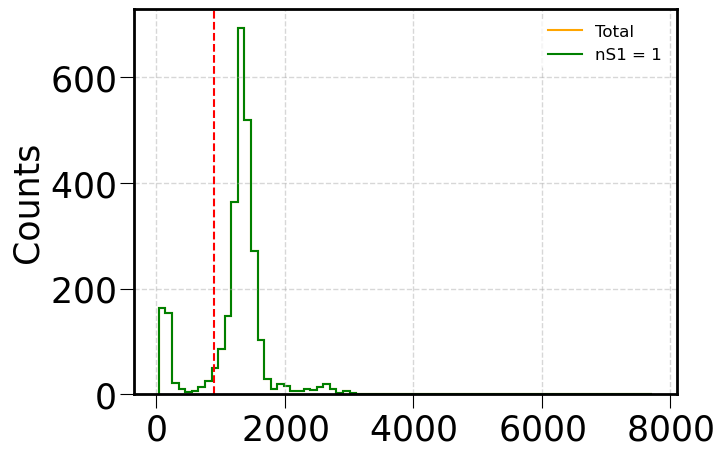

In [277]:
# Drop NaN values before creating histograms
main_S1e_corr_clean = df_file['S1e_corr'].dropna().unique()

# Histogram
total_counts, edges = np.histogram(main_S1e_corr_clean, bins=75)
one_s1_counts, _    = np.histogram(one_s1_events_df['S1e_corr'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(total_counts, edges, fill=False, ec='orange', lw=1.5, label='Total')
plt.stairs(one_s1_counts, edges, fill=False, ec='green', lw=1.5, label='nS1 = 1')

plt.axvline(x=S1_ENERGY_THRESHOLD, color='red', ls='--', lw=1.5)     # S1e_corr cut

# Styling
# plt.xlabel('Corrected S1 Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [278]:
one_s1_elec_like  = one_s1_events_df.loc[one_s1_events_df['S1e_corr'] <= S1_ENERGY_THRESHOLD, 'event'].unique()
one_s1_alpha_like = one_s1_events_df.loc[one_s1_events_df['S1e_corr'] >  S1_ENERGY_THRESHOLD, 'event'].unique()
print(f"Number of electron-like events: {len(one_s1_elec_like)} ({len(one_s1_elec_like) / one_s1_events_df['event'].nunique() :.2%})")
print(f"Number of alpha-like events: {len(one_s1_alpha_like)} ({len(one_s1_alpha_like) / one_s1_events_df['event'].nunique() :.2%})")

Number of electron-like events: 371 (15.09%)
Number of alpha-like events: 2133 (86.74%)


Take a look to some event displays

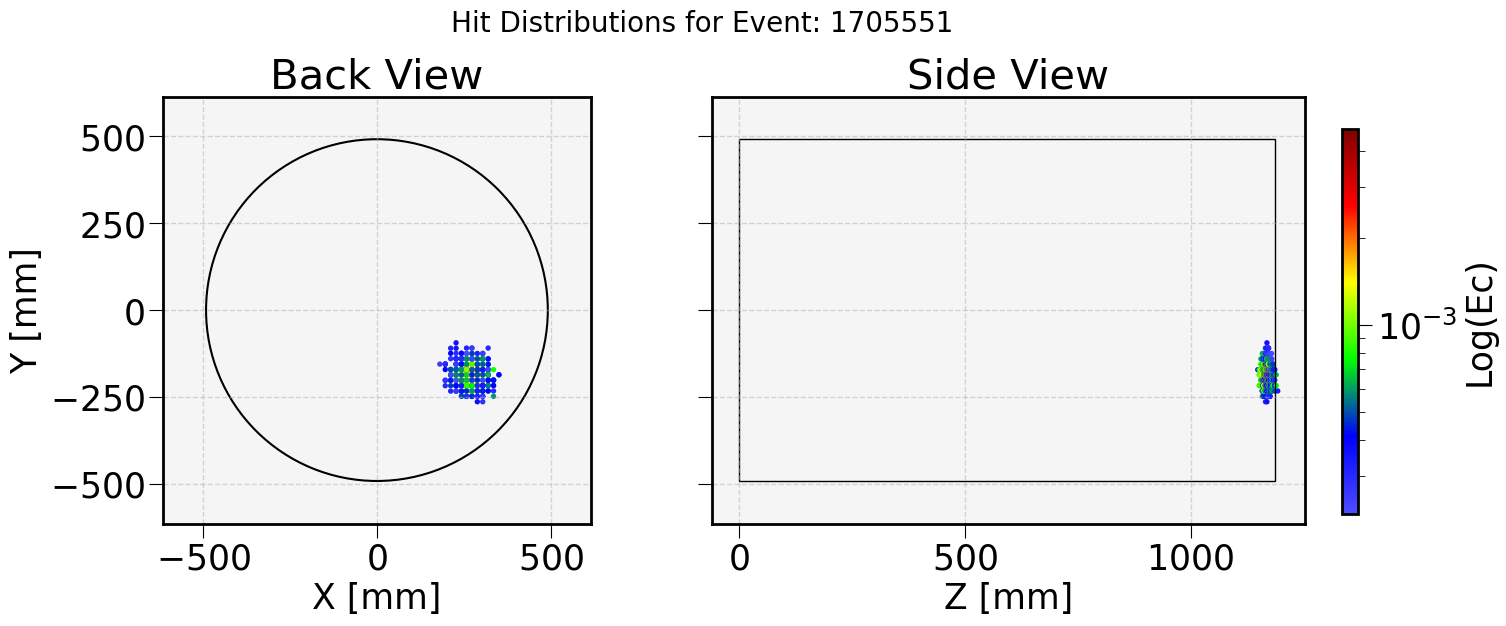

In [301]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(one_s1_elec_like))

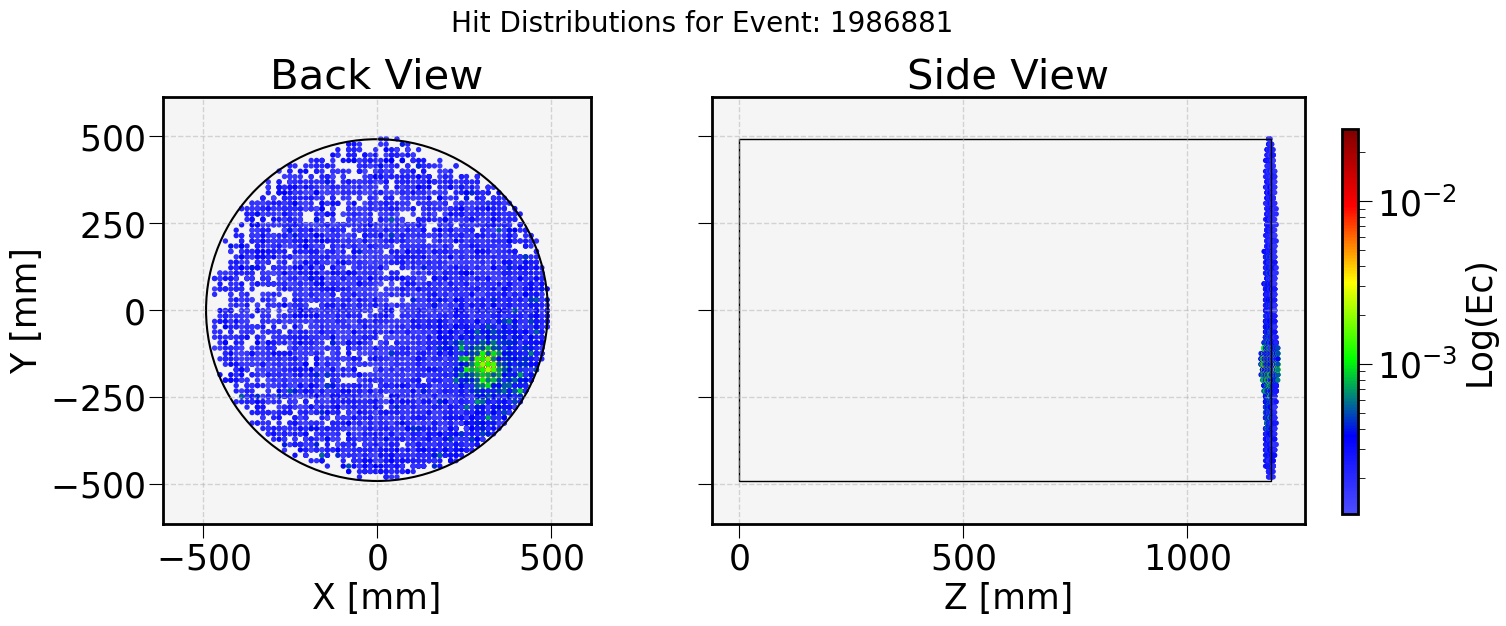

In [324]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(one_s1_alpha_like))

Mmm, how is the event size distribution for the alpha-like event (within $nS1=1$ category)?

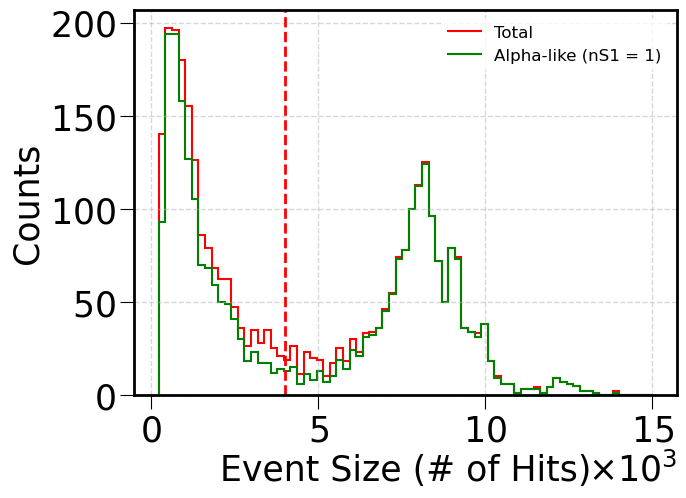

In [ ]:
# energy_based_one_s1_df = df_file[df_file['event'].isin(one_s1_alpha_like)].copy()

# # Histogram
# evt_size_counts, edges    = np.histogram(df_file['reco_size'].unique(), bins=75, range=(df_file['reco_size'].min(), 15e3))
# one_s1_evt_size_counts, _ = np.histogram(energy_based_one_s1_df['reco_size'].unique(), bins=edges)

# # Plotting
# plt.figure(figsize=(7, 5))
# plt.stairs(evt_size_counts, edges, fill=False, ec='red', lw=1.5, label='Total')
# plt.stairs(one_s1_evt_size_counts, edges, fill=False, ec='green', lw=1.5, label='Alpha-like (nS1 = 1)')

# plt.axvline(x=4e3, color='red', ls='--')     # Event size cut

# # Styling
# plt.xlabel('Event Size (# of Hits)')
# plt.ylabel('Counts')
# # plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
# plt.legend(fontsize=12)
# plt.grid(True)
# plt.show()

We can make a discrimination based on size after using $S1$ energy, but we may lose some electrons with high-energy or still taking degraded alphas
<br>
It is time to leave it in this way.

### Are we tagging properly?

In [325]:
print('In this test, we have...')
test_elec_ids  = np.union1d(zero_s1_elec_like, one_s1_elec_like)
test_alpha_ids = np.union1d(zero_s1_alpha_like, one_s1_alpha_like)
print(f" - {len(test_elec_ids)} electron-like events")
print(f" - {len(test_alpha_ids)} alpha-like events")

# ----- Tests ----- #
overlaped_events = np.intersect1d(test_elec_ids, test_alpha_ids)
if len(overlaped_events) > 0:
    print(f"ERROR: There are {len(overlaped_events)} overlaped events!\n       Event IDs: {overlaped_events.tolist()}")

untagged_events = np.setdiff1d(df_file['event'].unique(), np.union1d(test_elec_ids, test_alpha_ids))
if len(untagged_events) > 0:
    print(f"ERROR: There are {len(untagged_events)} untagged events!\n         Event IDs: {untagged_events}")

In this test, we have...
 - 629 electron-like events
 - 2214 alpha-like events
ERROR: There are 45 overlaped events!
       Event IDs: [41539, 83287, 84869, 140841, 149766, 161085, 195399, 219192, 226836, 378869, 394885, 555717, 616575, 655761, 1020594, 1029519, 1155204, 1304759, 1384013, 1504749, 1577213, 1777735, 1834834, 1941920, 1974771, 2059044, 2117634, 2141728, 2159571, 2222592, 2293460, 2324876, 2342740, 2365805, 2400784, 2467949, 2491861, 2555183, 2567685, 2576071, 2650600, 2773611, 2832082, 2850436, 2870274]


In [327]:
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,...,283.411778,-14.139397,1214.084635,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,...,102.168362,-156.682492,1184.950616,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,...,235.416304,15.217519,1177.726473,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,...,-365.991262,-244.065839,185.602276,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,...,424.900663,-134.443156,290.116533,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,...,-368.282912,246.661787,949.141978,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,...,-71.557856,-17.384803,1183.651875,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,...,309.230610,-146.521774,1187.221645,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,...,68.955353,231.732198,216.597186,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945


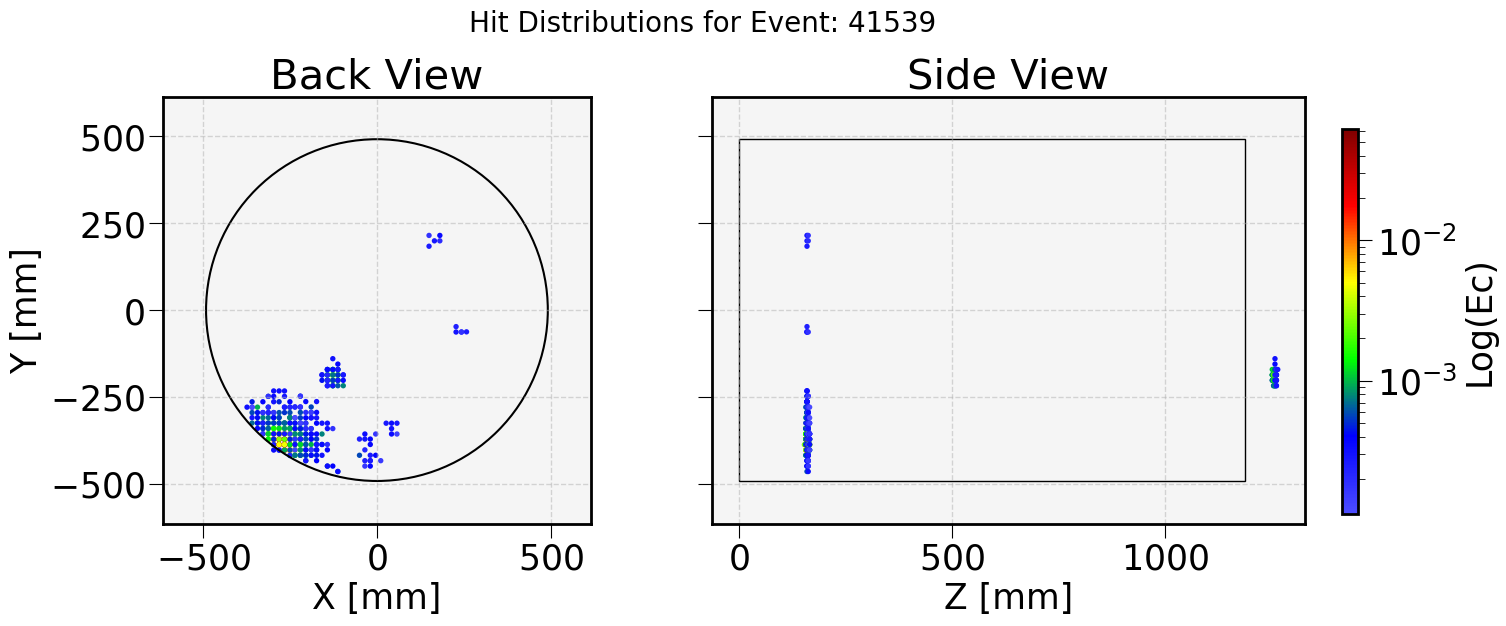

In [326]:
crudo.pt.event_display(df_soph, variable='Ec', event=41539)

### Execution

In [328]:
tagged_df_file = crudo.dm.tag_particles( df_file
                                       , size_threshold=SIZE_THRESHOLD
                                       , s1_energy_threshold=S1_ENERGY_THRESHOLD
                                       , event_column='event' )

In [329]:
# Split dataframes
electron_df = tagged_df_file[tagged_df_file['particle'] == 'electron'].copy()
alpha_df    = tagged_df_file[tagged_df_file['particle'] == 'alpha'].copy()
# Events ids
elec_ids  = electron_df.event.unique()
alpha_ids = alpha_df.event.unique()
print("After applying the tagging function, we have...")
print(f"  - {len(elec_ids)} electron-like events")
print(f"  - {len(alpha_ids)} alpha-like events")

# ----- Tests ----- #
if not np.array_equal(elec_ids, test_elec_ids):
    print("ERROR: Electron IDs do not match the test IDs!")
if not np.array_equal(alpha_ids, test_alpha_ids):
    print("ERROR: Alpha IDs do not match the test IDs!")

After applying the tagging function, we have...
  - 584 electron-like events
  - 2214 alpha-like events
ERROR: Electron IDs do not match the test IDs!


Let's see some event displays!

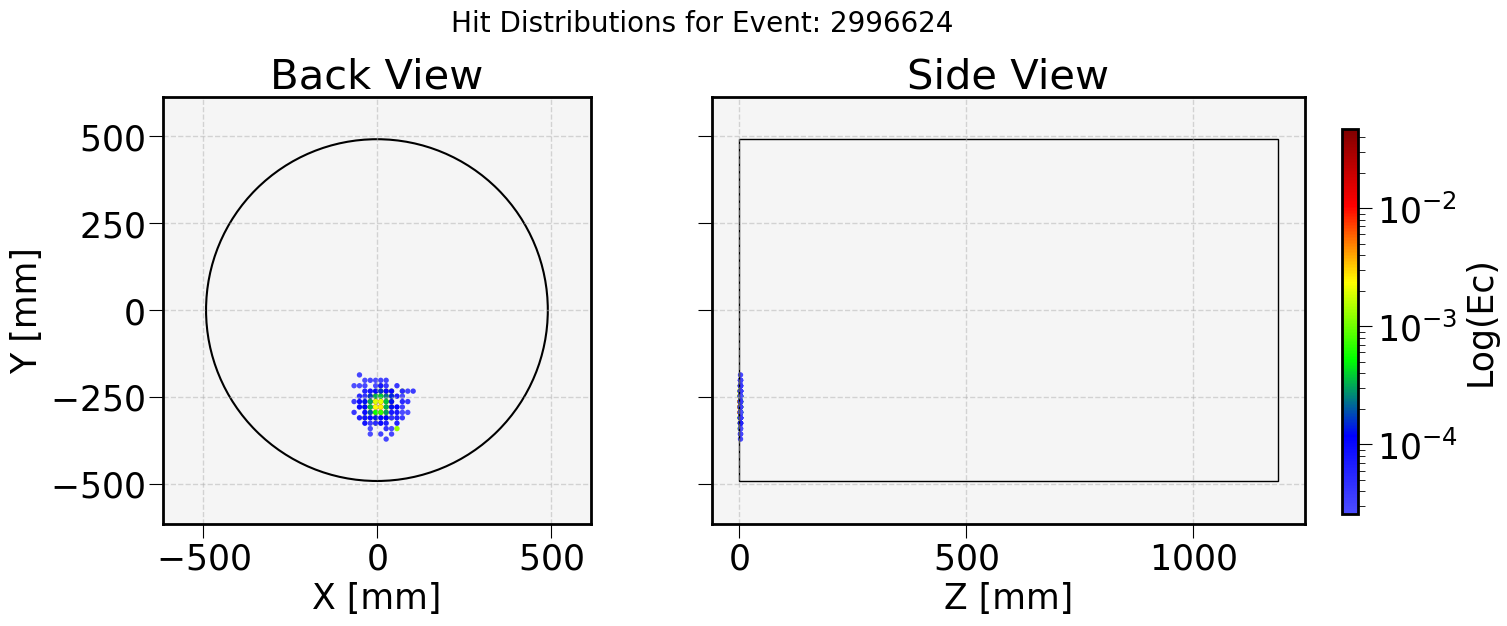

In [344]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(elec_ids))

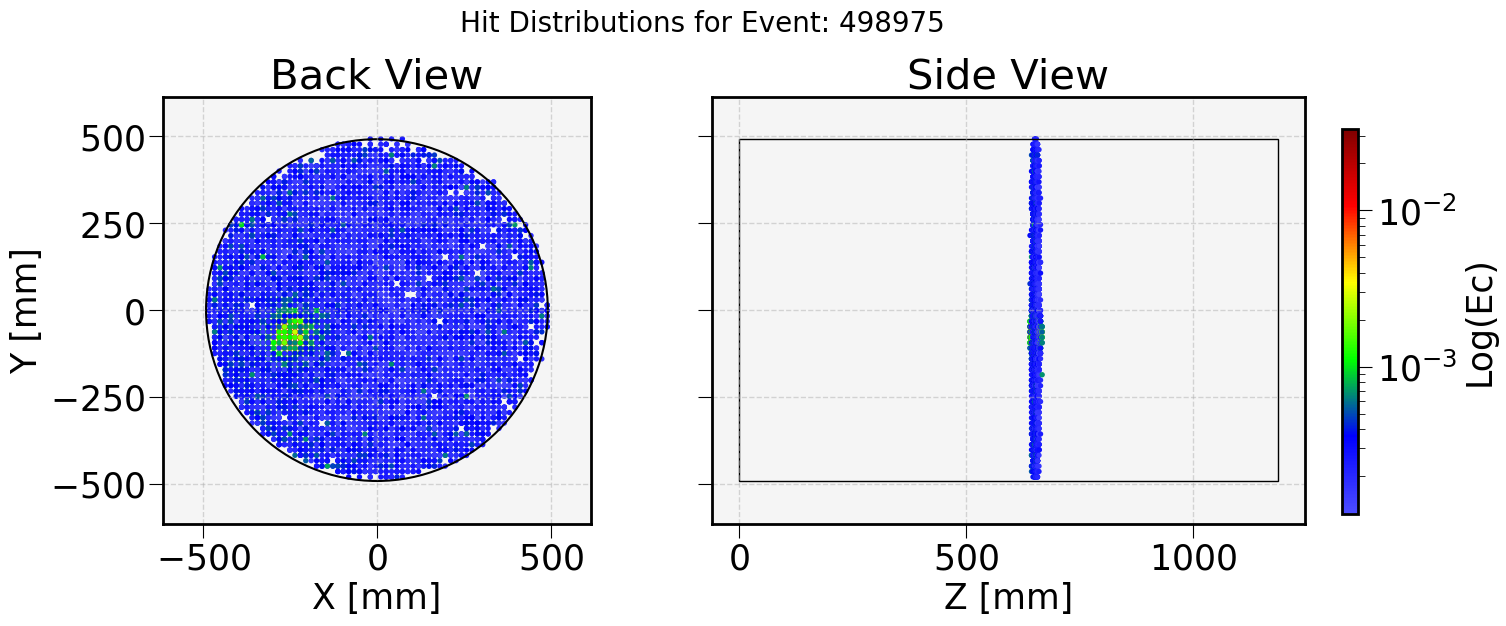

In [363]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(alpha_ids))

How is the energy spectrum?

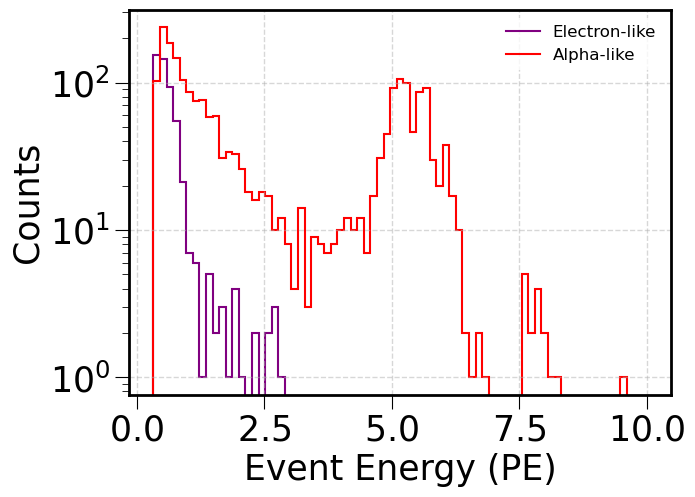

In [366]:
# Histogram
alpha_counts, edges = np.histogram(alpha_df['E_evt'].unique(), bins=75, range=(alpha_df['E_evt'].min(), 10))
elec_counts, _      = np.histogram(electron_df['E_evt'].unique(), bins=edges)

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(elec_counts, edges, fill=False, ec='purple', lw=1.5, label='Electron-like')
plt.stairs(alpha_counts, edges, fill=False, ec='red', lw=1.5, label='Alpha-like')

# plt.axvline(x=5.9, color='gray', ls='--', lw=2.0)     # 222Rn energy

# Styling
plt.xlabel('Event Energy (PE)')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [367]:
# --- Update Dataframe --- #
df_file = tagged_df_file.copy()

## By Detector Region

In [368]:
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,particle
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,...,-14.139397,1214.084635,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397,alpha
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,...,-156.682492,1184.950616,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751,alpha
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,...,15.217519,1177.726473,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133,electron
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,...,-244.065839,185.602276,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324,alpha
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,...,-134.443156,290.116533,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519,alpha
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,...,246.661787,949.141978,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490,alpha
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,...,-17.384803,1183.651875,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456,alpha
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,...,-146.521774,1187.221645,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680,alpha
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,...,231.732198,216.597186,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945,electron


In [369]:
df_soph

,event,time,npeak,X,Y,DT,Z,Ec,cluster,R_sq,X_w,Y_w,Z_w
0,729,1.758896e+09,0,-235.825,353.775,1399.086269,1210.209623,0.001667,0,180770.18125,-0.393116,0.589737,2.017399
1,729,1.758896e+09,0,-112.425,-417.725,1399.086269,1210.209623,0.001673,0,187133.55625,-0.188085,-0.698848,2.024664
2,729,1.758896e+09,0,181.025,122.525,1399.086269,1210.209623,0.001512,0,47782.42625,0.273628,0.185202,1.829287
3,729,1.758896e+09,0,-373.775,-279.275,1402.239644,1212.937292,0.001004,0,217702.27625,-0.375131,-0.280288,1.217339
4,729,1.758896e+09,0,-389.325,-93.675,1402.239644,1212.937292,0.000795,0,160348.96125,-0.309595,-0.074491,0.964539
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13666591,3013354,1.758983e+09,17,-359.225,-263.725,525.288500,454.374552,0.000415,1,198593.47625,-0.149125,-0.109480,0.188625
13666592,3013354,1.758983e+09,17,-343.675,-294.825,525.288500,454.374552,0.001419,1,205034.28625,-0.487645,-0.418331,0.644718
13666593,3013354,1.758983e+09,17,-343.675,-279.275,525.288500,454.374552,0.000985,1,196107.03125,-0.338417,-0.275003,0.447423
13666594,3013354,1.758983e+09,17,-328.125,-294.825,525.288500,454.374552,0.000403,1,194587.79625,-0.132117,-0.118709,0.182950


### Execution

In [370]:
region_tagged_df = crudo.dm.tag_event_by_detector_region( df_file
                                                        , z_cut_low=Z_LOW
                                                        , z_cut_high=Z_UP
                                                        , r_cut_high=R_UP
                                                        , event_column='event' )

Are these tags ok?

In [371]:
region_tagged_df

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,particle,region
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,...,1214.084635,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397,alpha,anode
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,...,1184.950616,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751,alpha,cathode
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,...,1177.726473,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133,electron,cathode
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,...,185.602276,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324,alpha,tube
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,...,290.116533,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519,alpha,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,...,949.141978,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490,alpha,tube
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,...,1183.651875,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456,alpha,cathode
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,...,1187.221645,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680,alpha,cathode
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,...,216.597186,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945,electron,fiducial


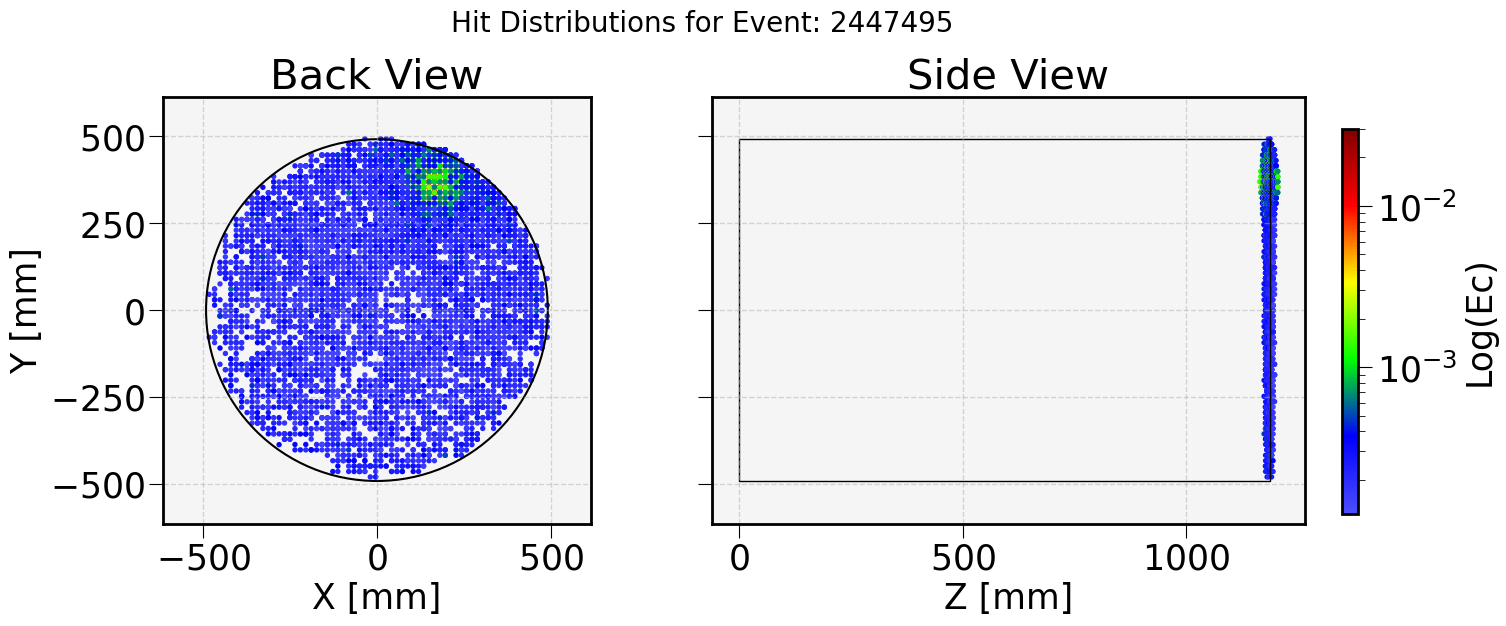

In [476]:
crudo.pt.event_display(df_soph, variable='Ec', event=np.random.choice(region_tagged_df.loc[region_tagged_df['region'] == 'cathode', 'event'].unique()))

And also, let's find the event counters

In [477]:
detector_region_counts = df_file.groupby(['particle', 'region'])['event'].nunique()
detector_region_counts

particle  region  
alpha     anode        115
          cathode      605
          tube        1494
electron  anode        266
          cathode      149
          fiducial      64
          tube         105
Name: event, dtype: int64

In [478]:
test_df = df_file[(df_file['particle'] == 'electron') & (df_file['region'] == 'cathode')].copy()
print(f"By using a dataframe: {test_df.event.nunique()}")
print(f"By using a series: {detector_region_counts.get(('electron', 'cathode'), 0)}")

# Verifiy if there are columns with uint64 type
uint64_columns = df_file.select_dtypes(include=['uint64']).columns
print("\nColumns with uint64 type:", uint64_columns)

By using a dataframe: 149
By using a series: 149

Columns with uint64 type: Index([], dtype='object')


# Trigger02 Window

We convert the event energy to MeV and apply the energy window cut.

In [481]:
df_file = crudo.ef.he_scale_converter(df_file, slope=M_HE_SCALE, intercept=B_HE_SCALE, input_column='E_evt', output_column='E_final')
df_file

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,particle,region,E_final
0,729,0,1,5050,1.758896e+09,NaN,NaN,NaN,NaN,NaN,...,-482.625,490.025,-479.925,492.725,1210.209623,1218.040684,502.050397,alpha,anode,3.088123
1,2129,1,1,8379,1.758896e+09,1371.259766,1360.743224,350.0,237.076340,49250.0,...,-482.625,490.025,-479.925,477.175,1167.136823,1204.521691,498.571751,alpha,cathode,4.991816
2,2402,1,1,886,1.758896e+09,160.021713,159.341187,525.0,29.957884,52750.0,...,149.925,335.525,-94.175,106.975,1162.166533,1199.741268,336.839133,electron,cathode,0.566660
3,2458,1,1,1253,1.758896e+09,696.163391,1186.814015,650.0,118.981293,1192325.0,...,-451.525,319.975,-464.375,383.875,179.669691,195.938070,496.294324,alpha,tube,1.325492
4,2899,1,1,1421,1.758896e+09,863.421326,1369.078537,825.0,146.900162,1073225.0,...,-359.225,490.025,-448.825,430.525,282.533112,298.484793,519.144519,alpha,tube,1.417207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3162,3010715,1,1,617,1.758983e+09,1236.313354,1361.195039,350.0,198.330582,310550.0,...,-435.975,-265.925,168.675,368.825,936.687956,963.602648,494.838490,alpha,tube,0.586630
3163,3011457,1,1,8461,1.758983e+09,1369.186157,1360.244285,350.0,239.161346,50425.0,...,-482.625,490.025,-479.925,492.725,1160.205146,1204.407078,500.173456,alpha,cathode,5.073709
3164,3011590,1,1,4522,1.758983e+09,983.265747,974.941037,625.0,167.346085,44025.0,...,-451.525,490.025,-479.925,461.625,1166.556841,1210.894794,496.213680,alpha,cathode,3.500285
3165,3012136,1,1,452,1.758983e+09,58.074413,97.005556,325.0,9.175889,1156100.0,...,-3.575,149.925,137.075,307.125,204.750149,231.540389,315.721945,electron,fiducial,0.427317


In [483]:
# Trigger 2 efficiency cut
trg2_mask = (df_file['E_final'] >= TRG2_THRESHOLD)
trg2_final_df, trg2_soph_df = crudo.dm.apply_cut_and_update(df_file, df_soph, cut_mask=trg2_mask, df_for_mask=df_file)

Let's see the energy spectrum

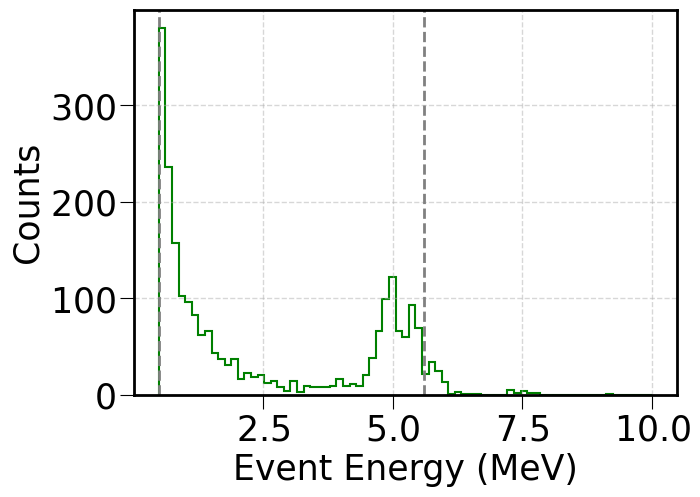

In [484]:
# Histogram
E_counts, edges = np.histogram(trg2_final_df['E_final'].unique(), bins=75, range=(trg2_final_df['E_final'].min(), 10))      # There are values up to ~20 MeV 

# Plotting
plt.figure(figsize=(7, 5))
plt.stairs(E_counts, edges, fill=False, ec='green', lw=1.5)

plt.axvline(x=0.5, color='gray', ls='--')     # Trigger02 threshold
plt.axvline(x=5.6, color='gray', ls='--')     # 222Rn energy

# Styling
plt.xlabel('Event Energy (MeV)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.grid(True)
plt.show()

In [485]:
# --- Update Dataframe --- #
df_file = trg2_final_df.copy()
df_soph = trg2_soph_df.copy()

print(f"After Trigger 2 efficiency cut: {df_file['event'].nunique()} events.")

After Trigger 2 efficiency cut: 2297 events.
